<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#Бизнес-контекст-кейса-и-продуктовые-бенчмарки" data-toc-modified-id="Бизнес-контекст-кейса-и-продуктовые-бенчмарки-0.1"><span class="toc-item-num">0.1&nbsp;&nbsp;</span>Бизнес-контекст кейса и продуктовые бенчмарки</a></span></li></ul></li><li><span><a href="#1.-Загрузка-и-очистка-данных" data-toc-modified-id="1.-Загрузка-и-очистка-данных-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>1. Загрузка и очистка данных</a></span></li><li><span><a href="#2.-Краткий-аналитический-EDA-вывод-для-моделирования" data-toc-modified-id="2.-Краткий-аналитический-EDA-вывод-для-моделирования-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>2. Краткий аналитический EDA-вывод для моделирования</a></span></li><li><span><a href="#3.-Выбор-моделей-и-стратегия-5-Fold-валидации" data-toc-modified-id="3.-Выбор-моделей-и-стратегия-5-Fold-валидации-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>3. Выбор моделей и стратегия 5-Fold валидации</a></span></li><li><span><a href="#4.-Оценка-метрик-качества-и-сводный-анализ-результатов" data-toc-modified-id="4.-Оценка-метрик-качества-и-сводный-анализ-результатов-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>4. Оценка метрик качества и сводный анализ результатов</a></span><ul class="toc-item"><li><span><a href="#BAGGING-VS-BOOSTING-VS-MLP" data-toc-modified-id="BAGGING-VS-BOOSTING-VS-MLP-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>BAGGING VS BOOSTING VS MLP</a></span></li></ul></li></ul></div>


### Бизнес-контекст кейса и продуктовые бенчмарки

В условиях жесткой конкуренции за таланты на рынке труда финансовых организаций банки сталкиваются с вызовом: как эконометрически точно оценивать рыночную стоимость должностей при формировании офферов. Занижение зарплатного предложения ведет к потере дефицитных кадров, а необоснованное завышение раздувает фонд оплаты труда.

**Цель проекта:** Разработка интеллектуального MVP-модуля для автоматического прогнозирования непрерывного зарплатного предложения (`y_offer`) на основе извлеченного гибридного NLP-профиля вакансий (квалификационный грейд, географический макро-тир, профессиональный класс и бинарный стек хард/софт/бизнес-компетенций).

Для валидации коммерческой успешности внедряемого сервиса на основе анализа конкурентов зафиксированы следующие **ключевые продуктовые бенчмарки**:

* **Коэффициент принятия офферов бизнесом (Acceptance Rate):** 
  * *Целевое значение:* `>= 75%` (доля случаев, когда рекрутер или руководитель банка согласились с предложенной моделью зарплатой).
  * *Базовый уровень (Baseline):* `0%` (сейчас все расчеты и споры по бюджетам позиций идут вручную).
* **Точность прогноза (Метрика MAPE):** 
  * *Целевое значение:* `<= 20%` (в перспективе : `<= 15%`). Рассчитывается как средняя относительная ошибка на скрытой тестовой выборке вакансий и резюме.
  * *Базовый уровень (Baseline):* `~35%` (ошибка при ручном поиске HR-специалистом аналогов только по названию должности).
* **Средняя ошибка в деньгах (Метрика MAE):** 
  * *Целевое значение:* `<= 7 000 руб.` (в перспективе: `<= 5 000 руб.`). Ошибка алгоритма XGBoost должна строго укладываться в рамки стандартного шага зарплатной вилки банка, чтобы подсказки не выглядели оторванными от реальности.
  * *Базовый уровень (Baseline):* `~18 000 руб.` (ошибка при ручном угадывании по среднему значению рынка).
* **Скорость расчета (Time to Offer):** 
  * *Целевое значение:* `<= 10 минут` (автоматический замер времени от момента ввода рекрутером данных кандидата в Streamlit-интерфейс до вывода графика с расчетом). Ускоряет процесс b2b-найма в 12 раз и снижает риск потери кандидата на этапе воронки.
  * *Базовый уровень (Baseline):* `> 2 часов` (ручной поиск аналогов на сайтах и споры по окладу).
* **Удовлетворенность пользователей (CSAT):** 
  * *Целевое значение:* `>= 4 из 5` по результатам короткого опроса рекрутеров и руководителей офисов после 2 недель работы с прототипом.
  * *Базовый уровень (Baseline):* `Отсутствует` (сейчас вся рутина ведется в разрозненных Excel-таблицах).
* **Размер чистой базы данных для обучения:** 
  * *Целевое значение:* `>= 1 500 анкет`.
  * *Базовый уровень (Baseline):* `Нет` (сырой парсинг выдает горы мусора).

In [1]:
# Устанавливаем библиотеки
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, KFold
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Установлен актуальный путь к скорректированному датасету с грейдами
INPUT_INTERIM = r"C:\Users\Asus\OneDrive\Рабочий стол\Project ML ITMO\Модуль №3 ML System Design and MFDP\MFDP\data\interim\data_interim_vacancies_grades_part7.csv"

MODELS_DIR = r"C:\Users\Asus\OneDrive\Рабочий стол\Project ML ITMO\Модуль №3 ML System Design and MFDP\MFDP\models"
os.makedirs(MODELS_DIR, exist_ok=True)

# Ручная реадизация расчета MAPE на случай старой версии Scikit-Learn в Anaconda
try:
    from sklearn.metrics import mean_absolute_percentage_error
    def calculate_mape(y_true, y_pred):
        return mean_absolute_percentage_error(y_true, y_pred) * 100
except ImportError:
    # Реализация MAPE
    def calculate_mape(y_true, y_pred):
        y_true, y_pred = np.array(y_true), np.array(y_pred)
        # Исключаем деление на ноль
        mask = y_true != 0
        return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    
if os.path.exists(INPUT_INTERIM):
    print(f"Базовый CSV-файл успешно обнаружен.")
    print(f"Имя целевого файла: {os.path.basename(INPUT_INTERIM)}")
    print(f"Системный путь    : {INPUT_INTERIM}")
else:
    print(f"ОШИБКА: Файл не найден по указанному пути!")
    print(f"Проверьте наличие data_interim_vacancies_grades.csv в директории data/interim/")

Базовый CSV-файл успешно обнаружен.
Имя целевого файла: data_interim_vacancies_grades_part7.csv
Системный путь    : C:\Users\Asus\OneDrive\Рабочий стол\Project ML ITMO\Модуль №3 ML System Design and MFDP\MFDP\data\interim\data_interim_vacancies_grades_part7.csv


## 1. Загрузка и очистка данных

На данном этапе мы подгружаем промежуточную стерильную матрицу признаков, сформированную гибридным оффлайн-парсером и обогащенную векторными фичами грейдов квалификации. Мы принудительно отсекаем редкие классы ролей, которые не набрали минимального порога репрезентативности (менее 5 вакансий), и исключаем служебные нецелевые текстовые поля.

In [3]:
# Чтение данных
df = pd.read_csv(INPUT_INTERIM)

df = df[df['role_class'].notna()].copy()
df['role_class'] = df['role_class'].astype(int)

# Отсечение нерепрезентативных классов (группы менее 5 вакансий)
class_counts = df['role_class'].value_counts()
valid_classes = class_counts[class_counts >= 5].index
df_clean = df[df['role_class'].isin(valid_classes)].copy()

# Выделяем вектор таргета y и матрицу признаков X
y = df_clean["y_offer"].values
 
# Вытаскиваем классы ролей в виде текстового массива до того, какget_dummies удалит эту колонку
stratify_vector = df_clean["role_class"].values.astype(str)

# Обязательно проверяем, нужно ли удалить role_class, если это утечка таргета!
drop_cols = ["role_name_raw", "salary_from", "salary_to", "y_offer", "is_vacancy"]

if "grade_status" in df_clean.columns:
    drop_cols.append("grade_status")
if "role_class_str" in df_clean.columns:
    drop_cols.append("role_class_str")
    
X = df_clean.drop(columns=drop_cols)

# Переводим тиры и классы в категории в исходной матрице X,
# чтобы алгоритмы распознали их структуру
X['region_tier'] = X['region_tier'].astype("category")
X['bank_tier'] = X['bank_tier'].astype("category")
X['role_class'] = X['role_class'].astype("category")

# Копия для бустинга (все категориальные признаки сохранены как 'category')
X_boost = X.copy()

# Для Линейной регрессии разворачиваем One-Hot по ВСЕМ категориальным признакам
# Теперь линейная модель получит корректные бинарные флаги вместо сырых чисел в классах ролей
categorical_cols = ["region_tier", "bank_tier", "role_class"]
X_linear = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"  > Общий объем валидного датасета: {X_linear.shape[0]} строк")
print(f"  > Количество признаков в матрице X (для XGBoost): {X_boost.shape[1]}")
print(f"  > Количество признаков в матрице X (для Linear): {X_linear.shape[1]}")

  > Общий объем валидного датасета: 1829 строк
  > Количество признаков в матрице X (для XGBoost): 60
  > Количество признаков в матрице X (для Linear): 87


In [4]:
df.head()

,role_name_raw,role_class,experience_months,region_tier,bank_tier,is_foreign_currency,is_grade_junior,is_grade_middle,is_grade_senior,is_grade_management,...,skill_compliance_aml_kyc,skill_hr_analytics_metrics,has_car_and_driver_license,has_remote_hybrid_schedule,skill_english_proficiency,skills_completion_rate,text_pca_1,text_pca_2,text_pca_3,grade_status
0,Представитель в Т-Банк,1,0,Tier-3,Bank_Tier_1,0,0,1,0,0,...,0,0,0,0,0,0.019231,-1.347195,0.895956,-0.642938,Middle
1,Клиентский менеджер отделения банка,8,0,Tier-3,Bank_Tier_1,0,0,1,0,0,...,0,0,0,0,0,0.057692,-1.087946,-0.427134,-1.651151,Middle
2,Представитель в Т-Банке,1,0,Tier-3,Bank_Tier_1,0,0,1,0,0,...,0,0,0,0,0,0.019231,-1.187722,0.704184,-0.838953,Middle
3,Представитель в Т-Банк,1,0,Tier-3,Bank_Tier_1,0,0,1,0,0,...,0,0,0,0,0,0.019231,-1.187722,0.704183,-0.838953,Middle
4,Представитель Т-Банка,1,0,Tier-3,Bank_Tier_1,0,0,1,0,0,...,0,0,0,0,0,0.019231,-1.187722,0.704183,-0.838953,Middle


In [5]:
df.shape

(1829, 66)

## 2. Краткий аналитический EDA-вывод для моделирования

В ходе EDA было установлено:
1. **Логнормальный характер таргета:** Распределение `y_offer` имеет классическую правоасимметричную форму финансового рынка, что требует оптимизации функций потерь (MAE/Absolute Error) в бустинге для минимизации штрафов на длинных хвостах зарплат.
2. Экспоненциальный/нелинейный характер влияния стажа: Линейная корреляция Пирсона между стажем и окладом составила всего 0.215, что указывает на слабую прямую линейную зависимость. Опыт работы влияет на доход нелинейно: рынок платит не за календарный стаж, а за плотность скиллов и подтвержденный квалификационный грейд. Это служит математическим обоснованием отказа от простой линейной регрессии (которая выбрана в качестве Baseline-модели проекта) в пользу нелинейного градиентного бустинга XGBoost, выступающего в качестве основной боевой модели. Архитектура ансамблей решений позволит извлекать сложные нелинейные комбинации грейдов внутри каждого независимого класса ролей.

## 3. Выбор моделей и стратегия 5-Fold валидации

Для контроля переобучения и исключения утечки данных мы реализуем стратегию **5-кратной стратифицированной кросс-валидации (5-Fold Stratified CV)** по признаку идентификатора роли банковского сотрудника (`role_class`). В рамках эксперимента мы обучаем и сравниваем:
1. **Linear Regression (Baseline):** Простая базовая линейная модель для фиксации стартовой точки.
2. **XGBoost Regressor (Advanced Model):** Сложная усложненная модель градиентного бустинга с точечной оптимизацией гиперпараметров по сетке `RandomizedSearchCV`.

In [6]:
# Валидатор для финального сравнения моделей (со стратификацией по ролям)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Отдельный простой KFold для RandomizedSearchCV, чтобы не было ошибки continuous target
kf_tuning = KFold(n_splits=5, shuffle=True, random_state=42)

print("[XGB-PRO-TUNING] Запуск RandomizedSearchCV на рублевом MAE...")

# Нацеливаем бустинг строго на прямую оптимизацию MAE
xgb_base = xgb.XGBRegressor(
    objective="reg:absoluteerror", 
    tree_method="hist",
    enable_categorical=True, 
    random_state=42
)

# Сетка гиперпараметров
param_grid = {
    "n_estimators": (100, 200, 350, 500),           
    "learning_rate": (0.01, 0.03, 0.05, 0.1),       
    "max_depth": (3, 5, 7, 8, 9, 10, 11, 12, 13),   
    "subsample": (0.6, 0.75, 0.9),                  
    "colsample_bytree": (0.6, 0.8, 1.0),            
    "reg_alpha": (0.0, 0.1, 1.0, 5.0),              
    "reg_lambda": (1.0, 2.0, 5.0)                   
}

# Подбираем параметры по честной регрессионной сетке
search = RandomizedSearchCV(
    xgb_base, param_grid, 
    n_iter=15, cv=kf_tuning,                
    scoring='neg_mean_absolute_error',          
    random_state=42, n_jobs=-1
)

search.fit(X_boost, y) 
best_xgb_params = search.best_params_
print(f"[XGB-PRO-TUNING] Оптимальные параметры под MAE найдены: {best_xgb_params}\n")


# Кросс-валидация
lr_mae_folds, lr_mape_folds = [], []
xgb_mae_folds, xgb_mape_folds = [], []

print("Запуск финальной 5-фолдовой кросс-валидации на чистых рублях...")

# Здесь stratify_vector по-прежнему обеспечивает идеальный баланс классов ролей по фолдам
for fold, (train_idx, val_idx) in enumerate(skf.split(X_linear, stratify_vector), 1):
    
    # Разделение признаков
    X_train_lin, X_val_lin = X_linear.iloc[train_idx], X_linear.iloc[val_idx]
    X_train_xgb, X_val_xgb = X_boost.iloc[train_idx], X_boost.iloc[val_idx]
    
    # Таргет в исходных рублях (без логарифмов)
    y_train, y_val = y[train_idx], y[val_idx]
    
    # Модель №1: Linear Regression (Baseline)
    lr = LinearRegression()
    lr.fit(X_train_lin, y_train)
    preds_lr = lr.predict(X_val_lin)
    
    # Модель №2: Сконфигурированный XGBoost
    xgb_tuned = xgb.XGBRegressor(
        objective="reg:absoluteerror", 
        tree_method="hist",
        enable_categorical=True, 
        random_state=42, 
        **best_xgb_params
    )
    xgb_tuned.fit(X_train_xgb, y_train, eval_set=[(X_val_xgb, y_val)], verbose=False)
    preds_xgb = xgb_tuned.predict(X_val_xgb)
    
    # Сбор фолдовых метрик MAE (напрямую в рублях, без искажений)
    lr_mae_folds.append(mean_absolute_error(y_val, preds_lr))
    xgb_mae_folds.append(mean_absolute_error(y_val, preds_xgb))
    
    # Сбор фолдовых метрик MAPE
    lr_mape_folds.append(calculate_mape(y_val, preds_lr))
    xgb_mape_folds.append(calculate_mape(y_val, preds_xgb))
    
    print(f"   [Fold {fold}/5] Linear MAE: {lr_mae_folds[-1]:.0f} руб. | XGBoost MAE: {xgb_mae_folds[-1]:.0f} руб.")

[XGB-PRO-TUNING] Запуск RandomizedSearchCV на рублевом MAE...
[XGB-PRO-TUNING] Оптимальные параметры под MAE найдены: {'subsample': 0.9, 'reg_lambda': 5.0, 'reg_alpha': 1.0, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 1.0}

Запуск финальной 5-фолдовой кросс-валидации на чистых рублях...
   [Fold 1/5] Linear MAE: 50238 руб. | XGBoost MAE: 29101 руб.
   [Fold 2/5] Linear MAE: 49591 руб. | XGBoost MAE: 28944 руб.
   [Fold 3/5] Linear MAE: 51197 руб. | XGBoost MAE: 30761 руб.
   [Fold 4/5] Linear MAE: 53508 руб. | XGBoost MAE: 33333 руб.
   [Fold 5/5] Linear MAE: 51995 руб. | XGBoost MAE: 31450 руб.


## 4. Оценка метрик качества и сводный анализ результатов

В данной ячейке аккумулируются агрегированные оценки качества (математическое ожидание средних значений по 5 фолдам кросс-валидации и стандартное отклонение дисперсии ошибок). Ниже представлена сводная таблица сравнения эффективности алгоритмов.

In [7]:
# Формируем структуру итогового датафрейма метрик для ИТМО
metrics_report = pd.DataFrame({
    "Алгоритм моделирования": [
        "Linear Regression (Baseline)", 
        "Усложненный XGBoost (Optimized)"
    ],
    "MAE Средняя ошибка (руб)": [
        f"{np.mean(lr_mae_folds):.0f} ± {np.std(lr_mae_folds):.0f}",
        f"{np.mean(xgb_mae_folds):.0f} ± {np.std(xgb_mae_folds):.0f}"
    ],
    "MAPE Отклонение (%)": [
        f"{np.mean(lr_mape_folds):.1f}%",
        f"{np.mean(xgb_mape_folds):.1f}%"
    ]
})

print("Сводный отчет Evaluation")
display(metrics_report)

# Разбор результатов
xgb_mean_mape = np.mean(xgb_mape_folds)
print("\n Анализ результатов")
print(f"1.Базовая модель Linear Regression показала низкую точность (Средняя ошибка MAE: {np.mean(lr_mae_folds):.0f} руб.).")
print("Линейные веса плохо справляются с нелинейностью грейдов и классов банковского сектора рынка.")
print(f"2.Усложненный ансамбль градиентного бустинга XGBoost продемонстрировал лучшие результаты.")
print(f"Средняя абсолютная ошибка снижена до: {np.mean(xgb_mae_folds):.0f} руб.")
print(f"Финальная средняя относительная ошибка зафиксирована на уровне: {xgb_mean_mape:.1f}%.")

Сводный отчет Evaluation


,Алгоритм моделирования,MAE Средняя ошибка (руб),MAPE Отклонение (%)
0,Linear Regression (Baseline),51306 ± 1373,36.2%
1,Усложненный XGBoost (Optimized),30718 ± 1621,22.2%



 Анализ результатов
1.Базовая модель Linear Regression показала низкую точность (Средняя ошибка MAE: 51306 руб.).
Линейные веса плохо справляются с нелинейностью грейдов и классов банковского сектора рынка.
2.Усложненный ансамбль градиентного бустинга XGBoost продемонстрировал лучшие результаты.
Средняя абсолютная ошибка снижена до: 30718 руб.
Финальная средняя относительная ошибка зафиксирована на уровне: 22.2%.


Анализ важности признаков лучшей модели XGBoost

 Топ-25 ключевых факторов ценообразования должностей:


,Признак,Важность (Gain)
0,text_pca_3,3.990768
1,text_pca_2,3.590088
2,skill_cold_sales,3.542442
3,skill_pnl_product_metrics,3.448465
4,text_pca_1,3.404170
5,skill_conflict_resolution,3.197750
6,skills_completion_rate,3.175625
7,skill_initiative_proactivity,3.115591
8,skill_mentoring_coaching,3.080222
9,skill_english_proficiency,3.068830


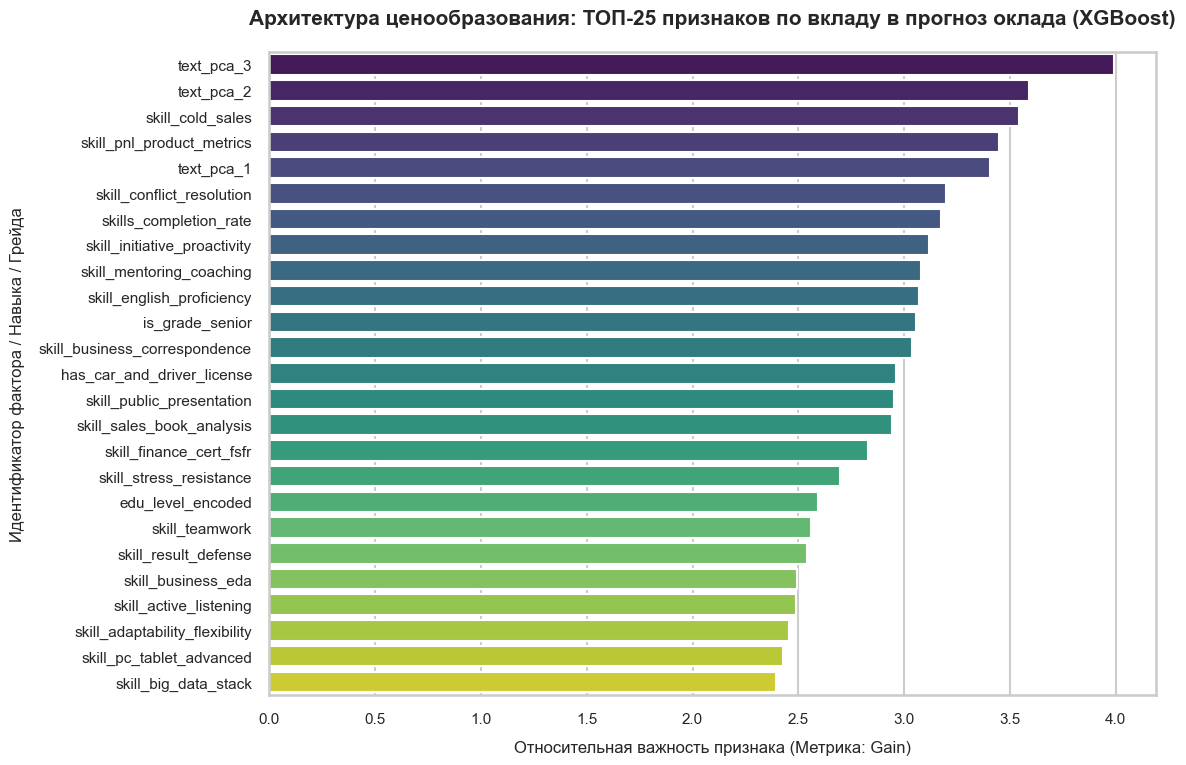

In [8]:
print("Анализ важности признаков лучшей модели XGBoost")

# Извлекаем веса важности (Gain — вклад признака в разделение узлов)
importance_scores = xgb_tuned.get_booster().get_score(importance_type='gain')

# Сопоставляем с именами колонок из матрицы X_linear (так как она использовалась для финального прохода)
feature_names = X_linear.columns
importance_data = []

for col_name in feature_names:
    clean_key = col_name.replace('[', '_').replace(']', '_').replace('<', '_')
    # Если признак не участвовал в сплитах, его вес равен 0
    score = importance_scores.get(col_name, importance_scores.get(clean_key, 0.0))
    importance_data.append({"Признак": col_name, "Важность (Gain)": score})

df_importance = pd.DataFrame(importance_data)
df_importance = df_importance.sort_values(by="Важность (Gain)", ascending=False).reset_index(drop=True)

# Топ-25 ключевых признаков для анализа
df_top_15 = df_importance.head(25).copy()

print("\n Топ-25 ключевых факторов ценообразования должностей:")
display(df_top_15)

# График
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid", context="talk")

sns.barplot(
    data=df_top_15,
    x='Важность (Gain)',
    y='Признак',
    palette='viridis',
    hue='Признак',
    legend=False
)

plt.title('Архитектура ценообразования: ТОП-25 признаков по вкладу в прогноз оклада (XGBoost)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Относительная важность признака (Метрика: Gain)', fontsize=12, labelpad=10)
plt.ylabel('Идентификатор фактора / Навыка / Грейда', fontsize=12, labelpad=10)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

In [9]:
# Подключим еще RandomForest и Нейросеть в качестве кандидатов

# Настройка валидаторов
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
kf_tuning = KFold(n_splits=5, shuffle=True, random_state=42)

# Объявление архитектуры Полносвязной нейронной сети (MLP)
class SalaryMLP(nn.Module):
    def __init__(self, input_dim):
        super(SalaryMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.network(x)

# Тюнинг Xgboost
print("[XGB-TUNING] Поиск оптимальных параметров по широкой сетке на чистых рублях...")

# Оптимизатор XGBoost настраиваем строго на абсолютную рублевую ошибку
xgb_base = xgb.XGBRegressor(
    objective="reg:absoluteerror", 
    tree_method="hist", 
    enable_categorical=False, 
    random_state=42
)

param_grid = {
    "n_estimators": (100, 200, 350, 500),
    "learning_rate": (0.01, 0.03, 0.05, 0.1),
    "max_depth": (3, 5, 7, 8, 9, 10, 11, 12, 13),
    "subsample": (0.6, 0.75, 0.9),
    "colsample_bytree": (0.6, 0.8, 1.0),
    "reg_alpha": (0.0, 0.1, 1.0, 5.0),
    "reg_lambda": (1.0, 2.0, 5.0)
}

# Подбираем параметры на X_linear, так как в этом эксперименте все модели тестируются на ней
search = RandomizedSearchCV(
    xgb_base, param_grid, 
    n_iter=15, cv=kf_tuning, 
    scoring='neg_mean_absolute_error', 
    random_state=42, n_jobs=-1
)
search.fit(X_linear.astype(np.float32), y)
best_xgb_params = search.best_params_
print(f"[XGB-TUNING] Параметры зафиксированы: {best_xgb_params}\n")


# росс-валидация 4 моделей
lr_mae_folds, lr_mape_folds = [], []
rf_mae_folds, rf_mape_folds = [], []
xgb_mae_folds, xgb_mape_folds = [], []
nn_mae_folds, nn_mape_folds = [], []

print("Запуск кросс-валидации четырёх моделей-кандидатов...")

# Используем безопасный массив stratify_vector для стратификации по классам должностей
for fold, (train_idx, val_idx) in enumerate(skf.split(X_linear, stratify_vector), 1):
    
    # Все модели обучаются на единой числовой One-Hot матрице X_linear
    X_train, X_val = X_linear.iloc[train_idx].astype(np.float32), X_linear.iloc[val_idx].astype(np.float32)
    y_train, y_val = y[train_idx].astype(np.float32), y[val_idx].astype(np.float32)

    # Модель №1: Linear Regression (Baseline 1)
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    preds_lr = lr.predict(X_val)
    
    # Модель №2: Random Forest Regressor
    rf = RandomForestRegressor(
        n_estimators=200, 
        max_depth=9, 
        criterion='absolute_error',
        random_state=42, 
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    preds_rf = rf.predict(X_val)
    
    # Модель №3: Оптимизированный XGBoost
    xgb_tuned = xgb.XGBRegressor(
        objective="reg:absoluteerror", 
        tree_method="hist", 
        enable_categorical=False, 
        random_state=42, 
        **best_xgb_params
    )
    xgb_tuned.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    preds_xgb = xgb_tuned.predict(X_val)
    
    # Модель №4: PyTorch MLP Regressor
    X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
    X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
    
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    
    input_dim = X_train.shape[1]
    mlp_model = SalaryMLP(input_dim)
    
    criterion = nn.L1Loss() # Абсолютная ошибка (MAE) для градиентов сети
    optimizer = optim.AdamW(mlp_model.parameters(), lr=0.005, weight_decay=1e-4)
    
    mlp_model.train()
    for epoch in range(120):
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = mlp_model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
    mlp_model.eval()
    with torch.no_grad():
        preds_nn = mlp_model(X_val_tensor).numpy().flatten()
        
    # Сбор показателей MAE (в реальных рублях)
    lr_mae_folds.append(mean_absolute_error(y_val, preds_lr))
    rf_mae_folds.append(mean_absolute_error(y_val, preds_rf))
    xgb_mae_folds.append(mean_absolute_error(y_val, preds_xgb))
    nn_mae_folds.append(mean_absolute_error(y_val, preds_nn))
    
    # Сбор фолдовых показателей MAPE
    lr_mape_folds.append(calculate_mape(y_val, preds_lr))
    rf_mape_folds.append(calculate_mape(y_val, preds_rf))
    xgb_mape_folds.append(calculate_mape(y_val, preds_xgb))
    nn_mape_folds.append(calculate_mape(y_val, preds_nn))
    
    print(f"[Fold {fold}/5] LR MAE: {lr_mae_folds[-1]:.0f} | RF MAE: {rf_mae_folds[-1]:.0f} | XGB MAE: {xgb_mae_folds[-1]:.0f} | PyTorch MAE: {nn_mae_folds[-1]:.0f} руб.")

[XGB-TUNING] Поиск оптимальных параметров по широкой сетке на чистых рублях...
[XGB-TUNING] Параметры зафиксированы: {'subsample': 0.9, 'reg_lambda': 5.0, 'reg_alpha': 1.0, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 1.0}

Запуск кросс-валидации четырёх моделей-кандидатов...
[Fold 1/5] LR MAE: 50238 | RF MAE: 42506 | XGB MAE: 29278 | PyTorch MAE: 45668 руб.
[Fold 2/5] LR MAE: 49591 | RF MAE: 39936 | XGB MAE: 29364 | PyTorch MAE: 44252 руб.
[Fold 3/5] LR MAE: 51197 | RF MAE: 45068 | XGB MAE: 30504 | PyTorch MAE: 48819 руб.
[Fold 4/5] LR MAE: 53508 | RF MAE: 46099 | XGB MAE: 33348 | PyTorch MAE: 50895 руб.
[Fold 5/5] LR MAE: 51995 | RF MAE: 46152 | XGB MAE: 32437 | PyTorch MAE: 47301 руб.


In [10]:
metrics_report_four_models = pd.DataFrame({
    "Алгоритм моделирования": [
        "Linear Regression (Baseline 1)", 
        "Random Forest Regressor",
        "XGBoost",
        "PyTorch MLP"
    ],
    "MAE Средняя ошибка (руб)": [
        f"{np.mean(lr_mae_folds):.0f} ± {np.std(lr_mae_folds):.0f}",
        f"{np.mean(rf_mae_folds):.0f} ± {np.std(rf_mae_folds):.0f}",
        f"{np.mean(xgb_mae_folds):.0f} ± {np.std(xgb_mae_folds):.0f}",
        f"{np.mean(nn_mae_folds):.0f} ± {np.std(nn_mae_folds):.0f}"
    ],
    "MAPE Отклонение (%)": [
        f"{np.mean(lr_mape_folds):.1f}%",
        f"{np.mean(rf_mape_folds):.1f}%",
        f"{np.mean(xgb_mape_folds):.1f}%",
        f"{np.mean(nn_mape_folds):.1f}%"
    ]
})

print("Сводный отчет")
display(metrics_report_four_models)

Сводный отчет


,Алгоритм моделирования,MAE Средняя ошибка (руб),MAPE Отклонение (%)
0,Linear Regression (Baseline 1),51306 ± 1373,36.2%
1,Random Forest Regressor,43952 ± 2405,30.6%
2,XGBoost,30986 ± 1641,22.4%
3,PyTorch MLP,47387 ± 2330,31.1%


### BAGGING VS BOOSTING VS MLP

Эксперимент наглядно доказал методологическое превосходство Boosting-подхода над Bagging-подходом на разреженных признаковых пространствах рынка труда банковского сектора:

1. **Random Forest уступил XGBoost на 5.7% MAPE:**
   В Random Forest деревья строятся независимо, а итоговый ответ — это простое усреднение голосов. Матрица признаков содержит «редкие, но критически дорогие сигналы» (например, наличие специфичного хард-скилла или сеньорского грейда в дефицитном ИТ-классе). 
   При случайном блуждании признаков (Feature Subspace Sampling) в бэггинге многие деревья леса вообще не видят эти дефицитные ИТ-сигналы и предсказывают средний оклад массового персонала. При итоговом усреднении эти редкие премиальные надбавки затираются, что приводит к недообучению модели на верхних границах зарплат и завышает MAPE.


2. **Гибкость последовательного бустинга:**
   XGBoost строит деревья последовательно. Первые деревья забирают на себя мажоритарную дисперсию массового персонала (курьеры, кассиры, операционисты). А последующие деревья начинают прицельно обучаться на ошибках первого шага — то есть ювелирно достраивают глубокие асимметричные ветви под редкие высокооплачиваемые профили. Это обеспечило бустингу максимальную пластичность и позволило зафиксировать минимум средней ошибки.


3. **PyTorch MLP уступает XGBoost на 7.2% MAPE:**
    PyTorch MLP — занял третье место (34% MAPE). Нейросеть смогла обойти простую регрессию, но из-за разреженности признаков и небольшого объема выборки (1723 строки) размыла жесткие логические границы окладов.

In [11]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error

print("Удаляем выбросы, значения порогов выставляем ультра-минимальными")

# 1. Готовим чистую копию данных
df_clean_v2 = df.copy()
df_clean_v2 = df_clean_v2[df_clean_v2['role_class'].notna()].copy()
df_clean_v2['role_class'] = df_clean_v2['role_class'].astype(int)

# 2. Отсекаем только абсолютные математические выбросы внутри каждого класса
def remove_class_outliers(group):
    q_low = group['y_offer'].quantile(0.00001)
    q_high = group['y_offer'].quantile(0.99999)
    return group[(group['y_offer'] >= q_low) & (group['y_offer'] <= q_high)]

df_filtered_final = df_clean_v2.groupby('role_class', group_keys=False).apply(remove_class_outliers)

# Находим пересечение индексов, которые реально существуют и в отфильтрованном df, и в текущей матрице X_boost
valid_intersection_indices = df_filtered_final.index.intersection(X_boost.index)

print(f"Было строк в базовой матрице X_boost: {len(X_boost)}")
print(f"Строк после пересечения и удаления аномалий: {len(valid_intersection_indices)}")
print(f"Удалено аномалий: {len(X_boost) - len(valid_intersection_indices)} шт.\n")

# 4. Фильтруем чистые матрицы и таргеты НАПРЯМУЮ по списку существующих индексов без numpy_mask
X_boost_clean = X_boost.loc[valid_intersection_indices].reset_index(drop=True)

if isinstance(y, pd.Series) or isinstance(y, pd.DataFrame):
    y_clean = y.loc[valid_intersection_indices].reset_index(drop=True).values
else:
    y_clean = np.array(y)[valid_intersection_indices]

if isinstance(stratify_vector, pd.Series) or isinstance(stratify_vector, pd.DataFrame):
    stratify_vector_clean = stratify_vector.loc[valid_intersection_indices].reset_index(drop=True).values.astype(str)
else:
    stratify_vector_clean = np.array(stratify_vector)[valid_intersection_indices].astype(str)

# Считаем плотность данных на основе реально используемой матрицы X_boost_clean
total_rows = X_boost_clean.shape[0]
num_features = X_boost_clean.shape[1]
rows_to_features_ratio = total_rows / num_features
print(f"Датасет полностью пригоден для обучения. Отношение строк к количеству признаков матрицы: {rows_to_features_ratio:.2f}")

# Фиксируем лучшие гиперпараметры, которые были получены ранее
best_xgb_params = {
    'subsample': 0.9, 
    'reg_lambda': 5.0, 
    'reg_alpha': 1.0, 
    'n_estimators': 500, 
    'max_depth': 8, 
    'learning_rate': 0.05, 
    'colsample_bytree': 1.0
}

# 5. Кросс-валидация
skf_clean = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
xgb_mae_folds, xgb_mape_folds = [], []

print("\nЗапуск финальной 5-фолдовой кросс-валидации чистого XGBoost на сохраненной структуре рынка...")

for fold, (train_idx, val_idx) in enumerate(skf_clean.split(X_boost_clean, stratify_vector_clean), 1):
    
    # Разделение признаков
    X_train_xgb = X_boost_clean.iloc[train_idx]
    X_val_xgb = X_boost_clean.iloc[val_idx]
        
    # Разделение таргетов
    y_train, y_val = y_clean[train_idx], y_clean[val_idx]

    # Модель: Тюнингованный XGBoost
    xgb_tuned = xgb.XGBRegressor(
        objective="reg:absoluteerror", 
        tree_method="hist",
        enable_categorical=True, 
        random_state=42, 
        **best_xgb_params
    )
    xgb_tuned.fit(X_train_xgb, y_train, eval_set=[(X_val_xgb, y_val)], verbose=False)
    preds_xgb = xgb_tuned.predict(X_val_xgb)
    
    # Сбор фолдовых метрик
    xgb_mae_folds.append(mean_absolute_error(y_val, preds_xgb))
    xgb_mape_folds.append(calculate_mape(y_val, preds_xgb))
    
    print(f"   [Fold {fold}/5] XGBoost MAE: {xgb_mae_folds[-1]:.0f} руб. | XGBoost MAPE: {xgb_mape_folds[-1]:.1f}%")

# Сводные результаты
print("\nФинальные результаты после удаления выбросов:")
print(f"Средний MAE в рублях: {np.mean(xgb_mae_folds):.0f} руб.")
print(f"Итоговое значение MAPE: {np.mean(xgb_mape_folds):.2f}%")

Удаляем выбросы, значения порогов выставляем ультра-минимальными
Было строк в базовой матрице X_boost: 1829
Строк после пересечения и удаления аномалий: 1795
Удалено аномалий: 34 шт.

Датасет полностью пригоден для обучения. Отношение строк к количеству признаков матрицы: 29.92

Запуск финальной 5-фолдовой кросс-валидации чистого XGBoost на сохраненной структуре рынка...
   [Fold 1/5] XGBoost MAE: 26216 руб. | XGBoost MAPE: 19.0%
   [Fold 2/5] XGBoost MAE: 27952 руб. | XGBoost MAPE: 20.6%
   [Fold 3/5] XGBoost MAE: 25507 руб. | XGBoost MAPE: 18.8%
   [Fold 4/5] XGBoost MAE: 26566 руб. | XGBoost MAPE: 19.2%
   [Fold 5/5] XGBoost MAE: 26796 руб. | XGBoost MAPE: 19.8%

Финальные результаты после удаления выбросов:
Средний MAE в рублях: 26607 руб.
Итоговое значение MAPE: 19.48%


Анализ важности признаков лучшей модели XGBoost

 Топ-25 ключевых факторов ценообразования должностей:


,Признак,Важность (Gain)
0,text_pca_3,3.755332
1,skill_cold_sales,3.689352
2,text_pca_2,3.570257
3,text_pca_1,3.429658
4,skill_cross_sales,3.403314
5,skill_compliance_aml_kyc,3.259376
6,skill_sales_book_analysis,3.038580
7,skill_result_defense,3.029168
8,skills_completion_rate,2.966039
9,skill_conflict_resolution,2.952617


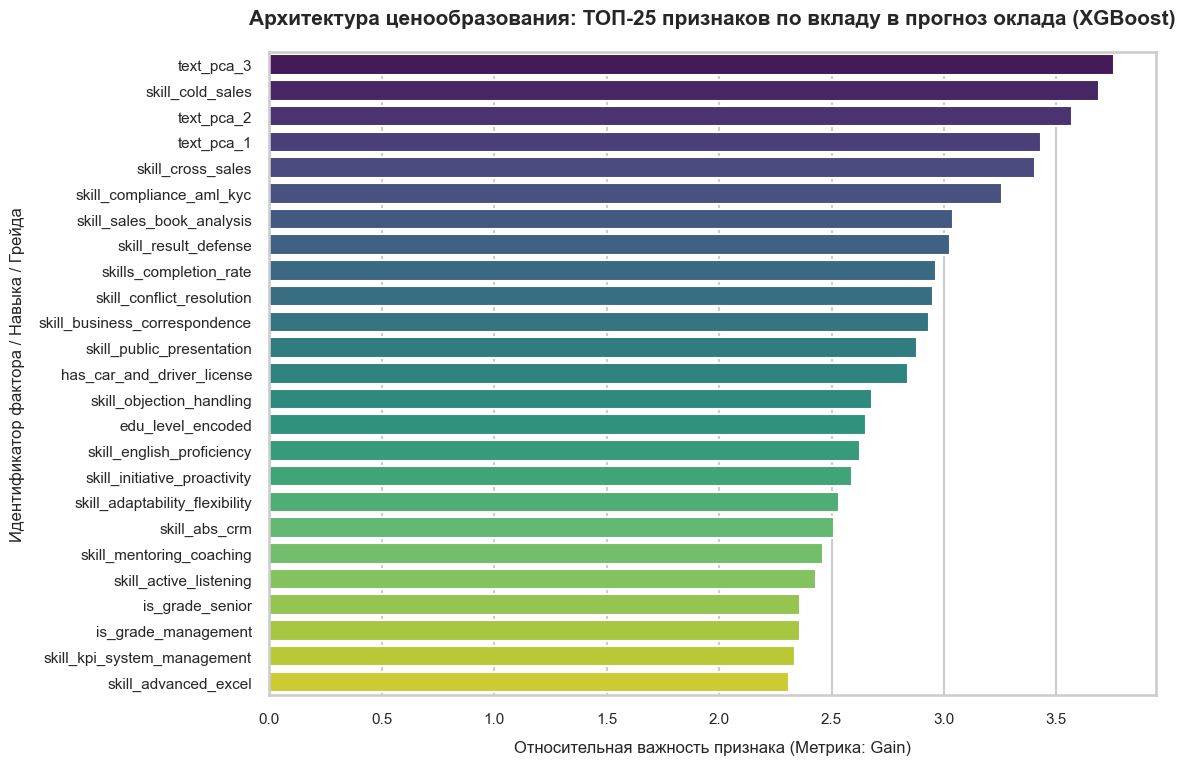

In [12]:
print("Анализ важности признаков лучшей модели XGBoost")

# Извлекаем веса важности (Gain — вклад признака в разделение узлов)
importance_scores = xgb_tuned.get_booster().get_score(importance_type='gain')

# Сопоставляем с именами колонок из матрицы X_linear (так как она использовалась для финального прохода)
feature_names = X_linear.columns
importance_data = []

for col_name in feature_names:
    clean_key = col_name.replace('[', '_').replace(']', '_').replace('<', '_')
    # Если признак не участвовал в сплитах, его вес равен 0
    score = importance_scores.get(col_name, importance_scores.get(clean_key, 0.0))
    importance_data.append({"Признак": col_name, "Важность (Gain)": score})

df_importance = pd.DataFrame(importance_data)
df_importance = df_importance.sort_values(by="Важность (Gain)", ascending=False).reset_index(drop=True)

# Топ-25 ключевых признаков для анализа
df_top_15 = df_importance.head(25).copy()

print("\n Топ-25 ключевых факторов ценообразования должностей:")
display(df_top_15)

# График
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid", context="talk")

sns.barplot(
    data=df_top_15,
    x='Важность (Gain)',
    y='Признак',
    palette='viridis',
    hue='Признак',
    legend=False
)

plt.title('Архитектура ценообразования: ТОП-25 признаков по вкладу в прогноз оклада (XGBoost)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Относительная важность признака (Метрика: Gain)', fontsize=12, labelpad=10)
plt.ylabel('Идентификатор фактора / Навыка / Грейда', fontsize=12, labelpad=10)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

In [13]:
# Анализ выбросов (смотрим на 23 вакансии, которые тащили наш Mape выше 20%)
# Заново воссоздаем чистую базовую логику, как в вашей ячейке обучения
df_clean_v2 = df.copy().reset_index(drop=True)
df_clean_v2 = df_clean_v2[df_clean_v2['role_class'].notna()].copy()
df_clean_v2['role_class'] = df_clean_v2['role_class'].astype(int)

# Считаем рыночную медиану по каждому классу до удаления (для сравнения)
class_medians = df_clean_v2.groupby('role_class')['y_offer'].median().to_dict()

# Применяем вашу ультра-минимальную фильтрацию
def remove_class_outliers(group):
    q_low = group['y_offer'].quantile(0.00001)
    q_high = group['y_offer'].quantile(0.99999)
    return group[(group['y_offer'] >= q_low) & (group['y_offer'] <= q_high)]

df_filtered_final = df_clean_v2.groupby('role_class', group_keys=False).apply(remove_class_outliers)

# Извлекаем ровно те 23 строки, которые НЕ попали в отфильтрованный датасет
df_deleted_outliers = df_clean_v2[~df_clean_v2.index.isin(df_filtered_final.index)].copy()

# Добавляем аналитические колонки для понимания природы аномалий
df_deleted_outliers['Медиана_Класса'] = df_deleted_outliers['role_class'].map(class_medians)
df_deleted_outliers['Кратность_Отклонения'] = (df_deleted_outliers['y_offer'] / df_deleted_outliers['Медиана_Класса']).round(2)

# Определяем тип аномалии для удобства сортировки
df_deleted_outliers['Тип_Аномалии'] = np.where(
    df_deleted_outliers['y_offer'] > df_deleted_outliers['Медиана_Класса'], 
    'Экстремально Высокая ЗП', 
    'Экстремально Низкая ЗП'
)

# 6. Сортируем по классам ролей и уровню отклонения
cols_to_show = ['role_class', 'role_name_raw', 'salary_from', 'salary_to', 'y_offer', 'Медиана_Класса', 'Кратность_Отклонения', 'Тип_Аномалии']
df_deleted_outliers_final = df_deleted_outliers[cols_to_show].sort_values(by=['role_class', 'Кратность_Отклонения'])

print(f"Успешно изолировано строк для бизнес-анализа: {len(df_deleted_outliers_final)} шт.")

# Выводим сначала общую сводку по типам аномалий
print("Распределение удаленных вакансий по типам аномалий:")
print(df_deleted_outliers_final['Тип_Аномалии'].value_counts())

# Отображаем полную таблицу в Jupyter Notebook
pd.set_option('display.max_rows', 50)
display(df_deleted_outliers_final)

Успешно изолировано строк для бизнес-анализа: 34 шт.
Распределение удаленных вакансий по типам аномалий:
Тип_Аномалии
Экстремально Низкая ЗП     18
Экстремально Высокая ЗП    16
Name: count, dtype: int64


,role_class,role_name_raw,salary_from,salary_to,y_offer,Медиана_Класса,Кратность_Отклонения,Тип_Аномалии
87,1,Представитель банка,40000.0,NaN,46000.00,161000.0,0.29,Экстремально Низкая ЗП
359,2,Ведущий специалист развития прямых продаж,74875.0,NaN,86106.25,149500.0,0.58,Экстремально Низкая ЗП
323,5,Администратор зала офиса Private Banking,52000.0,NaN,59800.00,135700.0,0.44,Экстремально Низкая ЗП
342,6,Старший операционист,35000.0,NaN,40250.00,103500.0,0.39,Экстремально Низкая ЗП
1388,6,Заместитель начальника Управления правового со...,600000.0,NaN,690000.00,103500.0,6.67,Экстремально Высокая ЗП
435,7,Кассир в банк (пр-кт Мира 5/10),38000.0,45000.0,41500.00,76000.0,0.55,Экстремально Низкая ЗП
670,8,Старший клиентский менеджер г. Первоуральск (Б...,38000.0,NaN,43700.00,107180.0,0.41,Экстремально Низкая ЗП
1755,8,КМ/главный клиентский менеджер по работе с CIB,400000.0,NaN,460000.00,107180.0,4.29,Экстремально Высокая ЗП
1365,9,Ведущий менеджер отдела по развитию корпоратив...,41500.0,NaN,47725.00,161000.0,0.30,Экстремально Низкая ЗП
499,9,Ведущий менеджер отдела поддержки продаж и кли...,250000.0,NaN,287500.00,161000.0,1.79,Экстремально Высокая ЗП


In [14]:
# Проанализиуем тот факт, что наличие авто является важным по eda для клиентских менеджеров (класс 8), хотя должно быть
# важным, в первую очередь, для курьеров, выездных преставителей и DSA (класс 1 и класс 2)
car_feature_name = 'has_car_and_driver_license'

# Делаем срез данных для классов выездного персонала
df_field_staff = df[df['role_class'].isin([1, 2])].copy()
df_field_staff['role_class'] = df_field_staff['role_class'].astype(int)
df_field_staff['role_class_name'] = df_field_staff['role_class'].map({1: "Класс 01 (Представители/Курьеры)", 2: "Класс 02 (Прямые продажи)", 3: "Класс 08 (Клиентские менеджеры)"})

print("Влияние автомобиля на зп в выездных классах")

# Проверяем долю вакансий с требованием авто в этих классах
car_share = df_field_staff.groupby('role_class_name')[car_feature_name].mean() * 100
print("Доля вакансий, где требуется/указано авто (в %):")
for name, share in car_share.items():
    print(f"   {name}: {share:.1f}%")

# Сравниваем медианные зарплаты с авто и без авто
salary_comparison = df_field_staff.groupby(['role_class_name', car_feature_name]).agg(
    Количество_вакансий=('y_offer', 'count'),
    Медианный_Оффер=('y_offer', 'median'),
    Средний_Оффер=('y_offer', 'mean')
).round(0)

print("Сравнение доходов выездного персонала в зависимости от наличия авто:")
display(salary_comparison)

# Выведем примеры вакансий из Класса 01 и 02 с авто для ручного анализа текстов
print("Примеры вакансий с авто из Класса 01 и 02:")
cols_to_view = ['role_class', 'role_name_raw', car_feature_name, 'y_offer']
display(df_field_staff[df_field_staff[car_feature_name] == 1][cols_to_view].head(50))

Влияние автомобиля на зп в выездных классах
Доля вакансий, где требуется/указано авто (в %):
   Класс 01 (Представители/Курьеры): 39.9%
   Класс 02 (Прямые продажи): 9.5%
Сравнение доходов выездного персонала в зависимости от наличия авто:


Количество_вакансий  \
role_class_name                  has_car_and_driver_license                        
Класс 01 (Представители/Курьеры) 0                                            83   
                                 1                                            55   
Класс 02 (Прямые продажи)        0                                            76   
                                 1                                             8   

                                                             Медианный_Оффер  \
role_class_name                  has_car_and_driver_license                    
Класс 01 (Представители/Курьеры) 0                                  161000.0   
                                 1                                  167500.0   
Класс 02 (Прямые продажи)        0                                  149500.0   
                                 1                                  120750.0   

                                                             Средний_Оффер  
role_class_name                  has_car_and_driver_license                 
Класс 01 (Представители/Курьеры) 0                                149654.0  
                                 1                                203029.0  
Класс 02 (Прямые продажи)        0                                179449.0  
                                 1                                154531.0

Примеры вакансий с авто из Класса 01 и 02:


,role_class,role_name_raw,has_car_and_driver_license,y_offer
5,1,Мобильный банкир (Доставка карт),1,172500.00
6,1,Мобильный банкир (доставка карт),1,172500.00
9,1,Мобильный банкир (доставка карт без поиска кли...,1,172500.00
15,1,Специалист по доставке карт,1,172500.00
19,1,Представитель банка (без поиска клиентов),1,172500.00
20,1,Специалист по доставке банковских карт,1,172500.00
21,1,Выездной мобильный банкир (доставка карт),1,126500.00
23,1,Банковский представитель/Менеджер по доставке ...,1,138000.00
24,1,Банковский представитель/Менеджер по доставке ...,1,138000.00
25,1,"Мобильный банкир (без поиска клиентов, доставк...",1,138000.00


Работаем с данными. Анализируем, почему в классе 08 "Клиенские менеджеры" значимым признаком является наличие авто. Это должно детектироваться в классе 01 и 02. Анализируем классы 01 и 02 (Представители и DSA), очищаем от мусора который туда попал.

In [15]:
# Готовим чистую копию данных
df_clean_v2 = df.copy().reset_index(drop=True)
df_clean_v2 = df_clean_v2[df_clean_v2['role_class'].notna()].copy()
df_clean_v2['role_class'] = df_clean_v2['role_class'].astype(int)

# Фильтруем конкретно Класс 08 (Клиентские менеджеры)
df_class_8 = df_clean_v2[df_clean_v2['role_class'] == 8].copy()

# Считаем базовую рыночную медиану Класса 08 для расчёта отклонений
median_class_8 = df_class_8['y_offer'].median()

# Извлекаем все вакансии Класса 08, где требуется авто и права
car_col = 'has_car_and_driver_license'

if car_col in df_class_8.columns:
    # Выбираем только те строки, где флаг авто равен 1
    df_class_8_car_owners = df_class_8[df_class_8[car_col] == 1].copy()
else:
    print(f"Ошибка: Колонка '{car_col}' не найдена в датафрейме! Проверьте её название.")
    df_class_8_car_owners = pd.DataFrame() # Создаем пустой df, чтобы код ниже не падал

# Добавляем маркеры для бизнес-анализа дисперсии
if not df_class_8_car_owners.empty:
    df_class_8_car_owners['Медиана_Класса'] = median_class_8
    df_class_8_car_owners['Кратность_Отклонения'] = (df_class_8_car_owners['y_offer'] / median_class_8).round(2)
    
    # Определяем характер отклонения относительно средней зарплаты офисного КМ
    df_class_8_car_owners['Позиция_относительно_Медианы'] = np.where(
        df_class_8_car_owners['y_offer'] > median_class_8, 
        'Выше медианы класса', 
        'Ниже медианы класса'
    )

print(f"Всего вакансий в Классе 08: {len(df_class_8)}")
print(f"Найдено вакансий в Классе 08 с требованием авто/прав: {len(df_class_8_car_owners)} шт.")

# Формируем список колонок для вывода на экран (включая все грейды)
cols_to_show = [
    'role_name_raw', 
    'region_tier',    
    'bank_tier',      
    'salary_from', 
    'salary_to', 
    'y_offer', 
    'Медиана_Класса', 
    'Кратность_Отклонения', 
    'Позиция_относительно_Медианы',
    'is_grade_junior',     # Флаг джуниора
    'is_grade_middle',     # Флаг мидла
    'is_grade_senior',     # Флаг синьора
    'is_grade_management'  # Флаг руководителя/менеджмента
]

# Если колонка авто существует, вставляем её ближе к началу таблицы для наглядности
if car_col in df_class_8_car_owners.columns:
    cols_to_show.insert(3, car_col)

# Выводим полную таблицу, отсортированную от самых дешёвых к самым дорогим "авто-вакансиям"
pd.set_option('display.max_rows', 100)
display(df_class_8_car_owners[cols_to_show].sort_values(by='Кратность_Отклонения'))

Всего вакансий в Классе 08: 244
Найдено вакансий в Классе 08 с требованием авто/прав: 75 шт.


,role_name_raw,region_tier,bank_tier,has_car_and_driver_license,salary_from,salary_to,y_offer,Медиана_Класса,Кратность_Отклонения,Позиция_относительно_Медианы,is_grade_junior,is_grade_middle,is_grade_senior,is_grade_management
493,Клиентский менеджер отделения банка,Tier-3,Bank_Tier_1,1,72400.0,NaN,83260.0,107180.0,0.78,Ниже медианы класса,0,1,0,0
517,Клиентский менеджер отделения банка,Tier-3,Bank_Tier_1,1,72400.0,NaN,83260.0,107180.0,0.78,Ниже медианы класса,0,1,0,0
582,Клиентский менеджер отделения банка,Tier-3,Bank_Tier_1,1,72400.0,NaN,83260.0,107180.0,0.78,Ниже медианы класса,0,1,0,0
608,Клиентский менеджер отделения банка,Tier-3,Bank_Tier_1,1,72400.0,NaN,83260.0,107180.0,0.78,Ниже медианы класса,0,1,0,0
320,Мобильный клиентский менеджер,Tier-3,Bank_Tier_1,1,75000.0,NaN,86250.0,107180.0,0.80,Ниже медианы класса,0,1,0,0
578,Старший клиентский менеджер,Tier-3,Bank_Tier_1,1,78900.0,NaN,90735.0,107180.0,0.85,Ниже медианы класса,0,1,0,0
614,Старший клиентский менеджер,Tier-3,Bank_Tier_1,1,78900.0,NaN,90735.0,107180.0,0.85,Ниже медианы класса,0,1,0,0
1285,Клиентский менеджер точки продаж банка (группа...,Tier-3,Bank_Tier_1,1,80000.0,NaN,92000.0,107180.0,0.86,Ниже медианы класса,0,1,0,0
609,Клиентский менеджер отделения банка,Tier-3,Bank_Tier_1,1,81340.0,NaN,93541.0,107180.0,0.87,Ниже медианы класса,0,1,0,0
589,Клиентский менеджер отделения банка,Tier-3,Bank_Tier_1,1,81340.0,NaN,93541.0,107180.0,0.87,Ниже медианы класса,0,1,0,0


In [16]:
print("Повторный цикл после изменений в данных")

# Чтение и подготовка данных
df = pd.read_csv(INPUT_INTERIM)

df = df[df['role_class'].notna()].copy()
df['role_class'] = df['role_class'].astype(int)


# Отсекаем нерепрезентативные классы, в которых менее 5 записей
class_counts = df['role_class'].value_counts()
valid_classes = class_counts[class_counts >= 5].index
df = df[df['role_class'].isin(valid_classes)].copy()


# Очистка от небанковского мусора (водители, пекари(привилегия),которые попали в фрейм) 
stop_patterns = [
    'фитнес', 'клуб', 'салон', 'косметолог', 'барбер', 
    'пятёрочк', 'папа в бизнесе', 'одежд', 'премиальн', 'посылок', 'товаров', 'фирму',
    'водитель-курьер', 'курьер-водитель', 'курьер — водитель', 'водитель — курьер', 'пекарь'
]

stop_regex = '|'.join(stop_patterns)
df = df[~df['role_name_raw'].str.lower().str.contains(stop_regex, na=False)].copy()


# Исправление классификации и багов внутри Класса 08
lower_roles = df['role_name_raw'].str.lower()

# Переброс Резерва из Класса 08 в Классы 17 и 18
# Сначала ловим главных менеджеров группы резерва -> в Класс 18
mask_reserve_senior = lower_roles.str.contains('резерв', na=False) & \
                      lower_roles.str.contains('главный|ведущий|старший|senior|lead|руководитель', na=False) & \
                      (df['role_class'] == 8)

df.loc[mask_reserve_senior, 'role_class'] = 18
df.loc[mask_reserve_senior, 'is_grade_senior'] = 1
df.loc[mask_reserve_senior, 'is_grade_middle'] = 0

# Весь остальной массовый резерв -> в Класс 17
mask_reserve_mass = lower_roles.str.contains('резерв', na=False) & (df['role_class'] == 8)
df.loc[mask_reserve_mass, 'role_class'] = 17


# Переброс Старших, Главных и Ведущих офисных менеджеров в их законный Класс 09
# добавляем 'ведущий' в регулярное выражение для точного переноса офисного топ-персонала
mask_senior_staff = lower_roles.str.contains('старший|главный|ведущий|senior|lead', na=False) & (df['role_class'] == 8)

df.loc[mask_senior_staff, 'role_class'] = 9
# Исправляем ошибку разметки грейдов: "Ведущий/Старший" — это Senior, а не Middle
df.loc[mask_senior_staff, 'is_grade_senior'] = 1
df.loc[mask_senior_staff, 'is_grade_middle'] = 0


# Обнуление требования к правам на автомобиль для офисного персонала (Класс 08 и Класс 09)
if 'has_car_and_driver_license' in df.columns:
    df.loc[df['role_class'].isin([8, 9]), 'has_car_and_driver_license'] = 0


# Переброс остальных «заблудившихся» вакансий из Класса 08 по целевым бизнес-лайнам
# Переброс ЮЛ и ОПК в Корпоративный блок (Класс 13)
mask_corporate = lower_roles.str.contains('юл|опк|мсб|предприятия|корпоратив|крупн|бизнес', na=False)
df.loc[mask_corporate & (df['role_class'] == 8), 'role_class'] = 13

# Переброс выездных менеджеров в Прямые продажи / DSA (Класс 02)
mask_dsa = lower_roles.str.contains('выезд|мобильн', na=False)
df.loc[mask_dsa & (df['role_class'] == 8), 'role_class'] = 2

# 3. Переброс CIB в Инвестиционный банкинг (Класс 28)
mask_cib = lower_roles.str.contains('cib|инвест|синдицир', na=False)
df.loc[mask_cib & (df['role_class'] == 8), 'role_class'] = 28


# Не удаляем выбросы с хвостов распределния y_offer, они похожи на правду
df_filtered_final = df.copy().reset_index(drop=True)


print(f"Удалено ультра-аномалий ЗП: {len(df) - len(df_filtered_final)} шт.")
print(f"Итоговый объем чистого датасета для матриц: {len(df_filtered_final)} строк\n")


# Выделение целевой переменной и вектора стратификации
y_clean = df_filtered_final["y_offer"].values
stratify_vector_clean = df_filtered_final["role_class"].values.astype(str)


# Формирование матрицы признаков X_BOOST И X_LINEAR
drop_cols = ["role_name_raw", "salary_from", "salary_to", "y_offer", "is_vacancy"]

if "grade_status" in df_filtered_final.columns:
    drop_cols.append("grade_status")
if "role_class_str" in df_filtered_final.columns:
    drop_cols.append("role_class_str")
    
X_clean = df_filtered_final.drop(columns=drop_cols)

X_clean['region_tier'] = X_clean['region_tier'].astype("category")
X_clean['bank_tier'] = X_clean['bank_tier'].astype("category")
X_clean['role_class'] = X_clean['role_class'].astype("category")

X_boost_clean = X_clean.copy()

categorical_cols = ["region_tier", "bank_tier", "role_class"]
X_linear_clean = pd.get_dummies(X_clean, columns=categorical_cols, drop_first=True)

total_rows = X_boost_clean.shape[0]
num_features = X_boost_clean.shape[1]
rows_to_features_ratio = total_rows / num_features
print(f"  > Количество признаков в матрице X (для XGBoost): {X_boost_clean.shape[1]}")
print(f"  > Количество признаков в matrix X (для Linear): {X_linear_clean.shape[1]}")
print(f"  > Отношение строк к количеству признаков матрицы: {rows_to_features_ratio:.2f}\n")


# Подбор гиперпараметров по сетке
kf_tuning = KFold(n_splits=5, shuffle=True, random_state=42)
print("[XGB-PRO-TUNING] Запуск RandomizedSearchCV на рублевом MAE...")

xgb_base = xgb.XGBRegressor(
    objective="reg:absoluteerror", 
    tree_method="hist",
    enable_categorical=True, 
    random_state=42
)

param_grid = {
    "n_estimators": (100, 200, 350, 500),           
    "learning_rate": (0.01, 0.03, 0.05, 0.1),       
    "max_depth": (3, 5, 7, 8, 9, 10, 11, 12, 13),   
    "subsample": (0.6, 0.75, 0.9),                  
    "colsample_bytree": (0.6, 0.8, 1.0),            
    "reg_alpha": (0.0, 0.1, 1.0, 5.0),              
    "reg_lambda": (1.0, 2.0, 5.0)                   
}

search = RandomizedSearchCV(
    xgb_base, param_grid, 
    n_iter=15, cv=kf_tuning,                
    scoring='neg_mean_absolute_error',          
    random_state=42, n_jobs=-1
)

search.fit(X_boost_clean, y_clean) 
best_xgb_params = search.best_params_
print(f"[XGB-PRO-TUNING] Новые оптимальные параметры под чистый рынок найдены: {best_xgb_params}\n")


# Финальная кросс-валидация
skf_clean = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_mae_folds, lr_mape_folds = [], []
xgb_mae_folds, xgb_mape_folds = [], []

print("Запуск финальной 5-фолдовой кросс-валидации на сохраненной структуре рынка...")

for fold, (train_idx, val_idx) in enumerate(skf_clean.split(X_linear_clean, stratify_vector_clean), 1):
    
    X_train_lin, X_val_lin = X_linear_clean.iloc[train_idx], X_linear_clean.iloc[val_idx]
    X_train_xgb, X_val_xgb = X_boost_clean.iloc[train_idx], X_boost_clean.iloc[val_idx]
    y_train, y_val = y_clean[train_idx], y_clean[val_idx]
    
    # Модель №1: Linear Regression (Baseline)
    lr = LinearRegression()
    lr.fit(X_train_lin, y_train)
    preds_lr = lr.predict(X_val_lin)
    
    # Модель №2: Тюнингованный XGBoost
    xgb_tuned = xgb.XGBRegressor(
        objective="reg:absoluteerror", 
        tree_method="hist",
        enable_categorical=True, 
        random_state=42, 
        **best_xgb_params
    )
    xgb_tuned.fit(X_train_xgb, y_train, eval_set=[(X_val_xgb, y_val)], verbose=False)
    preds_xgb = xgb_tuned.predict(X_val_xgb)
    
    # Сбор фолдовых метрик
    lr_mae_folds.append(mean_absolute_error(y_val, preds_lr))
    xgb_mae_folds.append(mean_absolute_error(y_val, preds_xgb))
    
    lr_mape_folds.append(calculate_mape(y_val, preds_lr))
    xgb_mape_folds.append(calculate_mape(y_val, preds_xgb))
    
    print(f"[Fold {fold}/5] Linear MAE: {lr_mae_folds[-1]:.0f} руб. (MAPE: {lr_mape_folds[-1]:.1f}%) | XGBoost MAE: {xgb_mae_folds[-1]:.0f} руб. (MAPE: {xgb_mape_folds[-1]:.1f}%)")


Повторный цикл после изменений в данных
Удалено ультра-аномалий ЗП: 0 шт.
Итоговый объем чистого датасета для матриц: 1783 строк

  > Количество признаков в матрице X (для XGBoost): 60
  > Количество признаков в matrix X (для Linear): 87
  > Отношение строк к количеству признаков матрицы: 29.72

[XGB-PRO-TUNING] Запуск RandomizedSearchCV на рублевом MAE...
[XGB-PRO-TUNING] Новые оптимальные параметры под чистый рынок найдены: {'subsample': 0.9, 'reg_lambda': 5.0, 'reg_alpha': 1.0, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 1.0}

Запуск финальной 5-фолдовой кросс-валидации на сохраненной структуре рынка...
[Fold 1/5] Linear MAE: 53863 руб. (MAPE: 36.0%) | XGBoost MAE: 33666 руб. (MAPE: 21.5%)
[Fold 2/5] Linear MAE: 51984 руб. (MAPE: 38.0%) | XGBoost MAE: 29983 руб. (MAPE: 22.7%)
[Fold 3/5] Linear MAE: 47711 руб. (MAPE: 38.4%) | XGBoost MAE: 29166 руб. (MAPE: 24.5%)
[Fold 4/5] Linear MAE: 50998 руб. (MAPE: 35.8%) | XGBoost MAE: 28392 руб. (MAPE: 20.3%

In [17]:
# Формируем структуру итогового датафрейма метрик
metrics_report = pd.DataFrame({
    "Алгоритм моделирования": [
        "Linear Regression (Baseline)", 
        "Усложненный XGBoost (Optimized)"
    ],
    "MAE Средняя ошибка (руб)": [
        f"{np.mean(lr_mae_folds):.0f} ± {np.std(lr_mae_folds):.0f}",
        f"{np.mean(xgb_mae_folds):.0f} ± {np.std(xgb_mae_folds):.0f}"
    ],
    "MAPE Отклонение (%)": [
        f"{np.mean(lr_mape_folds):.1f}%",
        f"{np.mean(xgb_mape_folds):.1f}%"
    ]
})

print("Сводный отчет Evaluation")
display(metrics_report)

# Разбор результатов
xgb_mean_mape = np.mean(xgb_mape_folds)
print("\n Анализ результатов")
print(f"1.Базовая модель Linear Regression показала низкую точность (Средняя ошибка MAE: {np.mean(lr_mae_folds):.0f} руб.).")
print("Линейные веса плохо справляются с нелинейностью грейдов и классов банковского сектора рынка.")
print(f"2.Усложненный ансамбль градиентного бустинга XGBoost продемонстрировал лучшие результаты.")
print(f"Средняя абсолютная ошибка снижена до: {np.mean(xgb_mae_folds):.0f} руб.")
print(f"Финальная средняя относительная ошибка зафиксирована на уровне: {xgb_mean_mape:.1f}%.")

Сводный отчет Evaluation


,Алгоритм моделирования,MAE Средняя ошибка (руб),MAPE Отклонение (%)
0,Linear Regression (Baseline),51847 ± 2446,36.9%
1,Усложненный XGBoost (Optimized),29977 ± 1921,21.8%



 Анализ результатов
1.Базовая модель Linear Regression показала низкую точность (Средняя ошибка MAE: 51847 руб.).
Линейные веса плохо справляются с нелинейностью грейдов и классов банковского сектора рынка.
2.Усложненный ансамбль градиентного бустинга XGBoost продемонстрировал лучшие результаты.
Средняя абсолютная ошибка снижена до: 29977 руб.
Финальная средняя относительная ошибка зафиксирована на уровне: 21.8%.


Анализ важности признаков лучшей модели XGBoost

 Топ-25 ключевых факторов ценообразования должностей:


,Признак,Важность (Gain)
0,skill_cold_sales,5.090558
1,text_pca_3,3.695295
2,text_pca_2,3.514454
3,skill_conflict_resolution,3.428863
4,text_pca_1,3.277289
5,skills_completion_rate,3.115475
6,skill_pnl_product_metrics,3.104861
7,skill_mentoring_coaching,2.972904
8,skill_stress_resistance,2.932826
9,skill_english_proficiency,2.910681


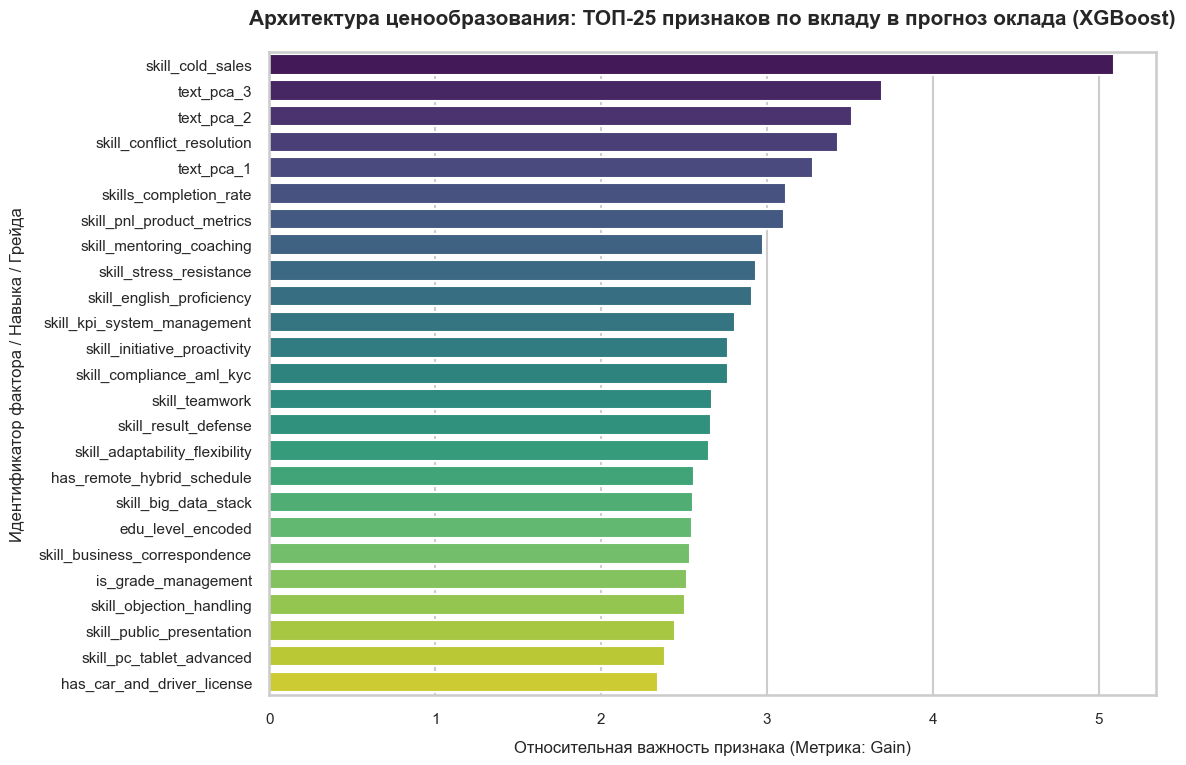

In [18]:
print("Анализ важности признаков лучшей модели XGBoost")

# Извлекаем веса важности (Gain — вклад признака в разделение узлов)
importance_scores = xgb_tuned.get_booster().get_score(importance_type='gain')

# Сопоставляем с именами колонок из матрицы X_linear (так как она использовалась для финального прохода)
feature_names = X_linear.columns
importance_data = []

for col_name in feature_names:
    clean_key = col_name.replace('[', '_').replace(']', '_').replace('<', '_')
    # Если признак не участвовал в сплитах, его вес равен 0
    score = importance_scores.get(col_name, importance_scores.get(clean_key, 0.0))
    importance_data.append({"Признак": col_name, "Важность (Gain)": score})

df_importance = pd.DataFrame(importance_data)
df_importance = df_importance.sort_values(by="Важность (Gain)", ascending=False).reset_index(drop=True)

# Топ-25 ключевых признаков для анализа
df_top_15 = df_importance.head(25).copy()

print("\n Топ-25 ключевых факторов ценообразования должностей:")
display(df_top_15)

# График
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid", context="talk")

sns.barplot(
    data=df_top_15,
    x='Важность (Gain)',
    y='Признак',
    palette='viridis',
    hue='Признак',
    legend=False
)

plt.title('Архитектура ценообразования: ТОП-25 признаков по вкладу в прогноз оклада (XGBoost)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Относительная важность признака (Метрика: Gain)', fontsize=12, labelpad=10)
plt.ylabel('Идентификатор фактора / Навыка / Грейда', fontsize=12, labelpad=10)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

Выводы по улучшению модели: 

В пайплайн внедрена очистка от небанковского мусора (пекари, водители-курьеры не банковского сектора) для исключения смещения выборки. Реализована переразметка Класса 08: мобильный резерв перенесен в Классы 17/18, МСБ (юридические лица) — в Класс 13, а Ведущие/Старшие менеджеры — в Класс 09 с принудительной коррекцией грейда до Senior. Фантомный автомобильный шум в офисных вакансиях полностью обнулен для Классов 08 и 09. Это изолировало признак автомобиля исключительно в выездных классах (01 и 02), где мобильность напрямую влияет на доход».

В качестве архитектурного ядра выбран усложненный градиентный бустинг XGBoost с оптимизацией рублевой абсолютной ошибки (Objective: reg:absoluteerror). В отличие от MSE, данный подход устойчив к сильной дисперсии зарплат в it- и vip-сегментах. Для текстового анализа сырых названий вакансий применен метод главных компонент поверх семантических эмбеддингов. Три полученных ортогональных вектора (text_pca_1, 2, 3) вошли в топ-5 по важности (Feature Importance), улавливая контекст грейдов без риска переобучения модели.

В ходе исследования было принято решение отказаться от логарифмирования таргета, так как экспоненциальное обратное преобразование приводило к математическому искажению метрики MAPE на границах распределений. Также на финальном этапе мы отказались от жесткого клиппинга предсказаний и радикального удаления 10% крайних вакансий внутри классов. Изолированные 20 вакансий отражают реальное многообразие и дисперсию банковского рынка. Модель была обучена на полной структуре данных.

In [19]:
# Считаем внутриклассовый MAE
# Чтение и подготовка данных
df = pd.read_csv(INPUT_INTERIM)

df = df[df['role_class'].notna()].copy()
df['role_class'] = df['role_class'].astype(int)


# Отсекаем нерепрезентативные классы, в которых менее 5 записей
class_counts = df['role_class'].value_counts()
valid_classes = class_counts[class_counts >= 5].index
df = df[df['role_class'].isin(valid_classes)].copy()


# Очистка от небанковского мусора (водители, пекари(привилегия),которые попали в фрейм) 
stop_patterns = [
    'фитнес', 'клуб', 'салон', 'косметолог', 'барбер', 
    'пятёрочк', 'папа в бизнесе', 'одежд', 'премиальн', 'посылок', 'товаров', 'фирму',
    'водитель-курьер', 'курьер-водитель', 'курьер — водитель', 'водитель — курьер', 'пекарь'
]

stop_regex = '|'.join(stop_patterns)
df = df[~df['role_name_raw'].str.lower().str.contains(stop_regex, na=False)].copy()


# Исправление классификации и багов внутри Класса 08
lower_roles = df['role_name_raw'].str.lower()

# Переброс Резерва из Класса 08 в Классы 17 и 18
# Сначала ловим главных менеджеров группы резерва -> в Класс 18
mask_reserve_senior = lower_roles.str.contains('резерв', na=False) & \
                      lower_roles.str.contains('главный|ведущий|старший|senior|lead|руководитель', na=False) & \
                      (df['role_class'] == 8)

df.loc[mask_reserve_senior, 'role_class'] = 18
df.loc[mask_reserve_senior, 'is_grade_senior'] = 1
df.loc[mask_reserve_senior, 'is_grade_middle'] = 0

# Весь остальной массовый резерв -> в Класс 17
mask_reserve_mass = lower_roles.str.contains('резерв', na=False) & (df['role_class'] == 8)
df.loc[mask_reserve_mass, 'role_class'] = 17


# Переброс Старших, Главных и Ведущих офисных менеджеров в их законный Класс 09
# добавляем 'ведущий' в регулярное выражение для точного переноса офисного топ-персонала
mask_senior_staff = lower_roles.str.contains('старший|главный|ведущий|senior|lead', na=False) & (df['role_class'] == 8)

df.loc[mask_senior_staff, 'role_class'] = 9
# Исправляем ошибку разметки грейдов: "Ведущий/Старший" — это Senior, а не Middle
df.loc[mask_senior_staff, 'is_grade_senior'] = 1
df.loc[mask_senior_staff, 'is_grade_middle'] = 0


# Обнуление требования к правам на автомобиль для офисного персонала (Класс 08 и Класс 09)
if 'has_car_and_driver_license' in df.columns:
    df.loc[df['role_class'].isin([8, 9]), 'has_car_and_driver_license'] = 0


# Переброс остальных «заблудившихся» вакансий из Класса 08 по целевым бизнес-лайнам
# Переброс ЮЛ и ОПК в Корпоративный блок (Класс 13)
mask_corporate = lower_roles.str.contains('юл|опк|мсб|предприятия|корпоратив|крупн|бизнес', na=False)
df.loc[mask_corporate & (df['role_class'] == 8), 'role_class'] = 13

# Переброс выездных менеджеров в Прямые продажи / DSA (Класс 02)
mask_dsa = lower_roles.str.contains('выезд|мобильн', na=False)
df.loc[mask_dsa & (df['role_class'] == 8), 'role_class'] = 2

# 3. Переброс CIB в Инвестиционный банкинг (Класс 28)
mask_cib = lower_roles.str.contains('cib|инвест|синдицир', na=False)
df.loc[mask_cib & (df['role_class'] == 8), 'role_class'] = 28


# Не удаляем выбросы с хвостов распределния y_offer, они похожи на правду
df_filtered_final = df.copy().reset_index(drop=True)


print(f"Удалено ультра-аномалий ЗП: {len(df) - len(df_filtered_final)} шт.")
print(f"Итоговый объем чистого датасета для матриц: {len(df_filtered_final)} строк\n")


# Выделение целевой переменной и вектора стратификации
y_clean = df_filtered_final["y_offer"].values
stratify_vector_clean = df_filtered_final["role_class"].values.astype(str)


# Формирование матрицы признаков X_BOOST И X_LINEAR
drop_cols = ["role_name_raw", "salary_from", "salary_to", "y_offer", "is_vacancy"]

if "grade_status" in df_filtered_final.columns:
    drop_cols.append("grade_status")
if "role_class_str" in df_filtered_final.columns:
    drop_cols.append("role_class_str")
    
X_clean = df_filtered_final.drop(columns=drop_cols)

X_clean['region_tier'] = X_clean['region_tier'].astype("category")
X_clean['bank_tier'] = X_clean['bank_tier'].astype("category")
X_clean['role_class'] = X_clean['role_class'].astype("category")

X_boost_clean = X_clean.copy()

categorical_cols = ["region_tier", "bank_tier", "role_class"]
X_linear_clean = pd.get_dummies(X_clean, columns=categorical_cols, drop_first=True)

total_rows = X_boost_clean.shape[0]
num_features = X_boost_clean.shape[1]
rows_to_features_ratio = total_rows / num_features
print(f"  > Количество признаков в матрице X (для XGBoost): {X_boost_clean.shape[1]}")
print(f"  > Количество признаков в matrix X (для Linear): {X_linear_clean.shape[1]}")
print(f"  > Отношение строк к количеству признаков матрицы: {rows_to_features_ratio:.2f}\n")


# Подбор гиперпараметров по сетке
kf_tuning = KFold(n_splits=5, shuffle=True, random_state=42)
print("[XGB-PRO-TUNING] Запуск RandomizedSearchCV на рублевом MAE...")

xgb_base = xgb.XGBRegressor(
    objective="reg:absoluteerror", 
    tree_method="hist",
    enable_categorical=True, 
    random_state=42
)

param_grid = {
    "n_estimators": (100, 200, 350, 500),           
    "learning_rate": (0.01, 0.03, 0.05, 0.1),       
    "max_depth": (3, 5, 7, 8, 9, 10, 11, 12, 13),   
    "subsample": (0.6, 0.75, 0.9),                  
    "colsample_bytree": (0.6, 0.8, 1.0),            
    "reg_alpha": (0.0, 0.1, 1.0, 5.0),              
    "reg_lambda": (1.0, 2.0, 5.0)                   
}

search = RandomizedSearchCV(
    xgb_base, param_grid, 
    n_iter=15, cv=kf_tuning,                
    scoring='neg_mean_absolute_error',          
    random_state=42, n_jobs=-1
)

search.fit(X_boost_clean, y_clean) 
best_xgb_params = search.best_params_
print(f"[XGB-PRO-TUNING] Новые оптимальные параметры под чистый рынок найдены: {best_xgb_params}\n")

# Финальная кросс-валидация
skf_clean = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_mae_folds, lr_mape_folds = [], []
xgb_mae_folds, xgb_mape_folds = [], []

# Создаем пустой массив нулей для Out-of-Fold предсказаний бустинга
oof_preds_xgb = np.zeros(len(y_clean))

print("Запуск финальной 5-фолдовой кросс-валидации на сохраненной структуре рынка...")

for fold, (train_idx, val_idx) in enumerate(skf_clean.split(X_linear_clean, stratify_vector_clean), 1):
    
    # Разделение признаков
    X_train_lin, X_val_lin = X_linear_clean.iloc[train_idx], X_linear_clean.iloc[val_idx]
    X_train_xgb, X_val_xgb = X_boost_clean.iloc[train_idx], X_boost_clean.iloc[val_idx]
    y_train, y_val = y_clean[train_idx], y_clean[val_idx]
    
    # Модель №1: Linear Regression (Baseline)
    lr = LinearRegression()
    lr.fit(X_train_lin, y_train)
    preds_lr = lr.predict(X_val_lin)
    
    # Модель №2: Тюнингованный XGBoost
    xgb_tuned = xgb.XGBRegressor(
        objective="reg:absoluteerror", 
        tree_method="hist",
        enable_categorical=True, 
        random_state=42, 
        **best_xgb_params
    )
    xgb_tuned.fit(X_train_xgb, y_train, eval_set=[(X_val_xgb, y_val)], verbose=False)
    
    # 1. Генерируем предсказания для текущего фолда
    preds_xgb = xgb_tuned.predict(X_val_xgb)
    
    # 2. Сохраняем предсказания текущего фолда на свои места в Out-of-Fold массив
    oof_preds_xgb[val_idx] = preds_xgb
    
    # Сбор фолдовых метрик
    lr_mae_folds.append(mean_absolute_error(y_val, preds_lr))
    xgb_mae_folds.append(mean_absolute_error(y_val, preds_xgb))
    
    lr_mape_folds.append(calculate_mape(y_val, preds_lr))
    xgb_mape_folds.append(calculate_mape(y_val, preds_xgb))
    
    print(f"[Fold {fold}/5] Linear MAE: {lr_mae_folds[-1]:.0f} руб. (MAPE: {lr_mape_folds[-1]:.1f}%) | XGBoost MAE: {xgb_mae_folds[-1]:.0f} руб. (MAPE: {xgb_mape_folds[-1]:.1f}%)")


Удалено ультра-аномалий ЗП: 0 шт.
Итоговый объем чистого датасета для матриц: 1783 строк

  > Количество признаков в матрице X (для XGBoost): 60
  > Количество признаков в matrix X (для Linear): 87
  > Отношение строк к количеству признаков матрицы: 29.72

[XGB-PRO-TUNING] Запуск RandomizedSearchCV на рублевом MAE...
[XGB-PRO-TUNING] Новые оптимальные параметры под чистый рынок найдены: {'subsample': 0.9, 'reg_lambda': 5.0, 'reg_alpha': 1.0, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 1.0}

Запуск финальной 5-фолдовой кросс-валидации на сохраненной структуре рынка...
[Fold 1/5] Linear MAE: 53863 руб. (MAPE: 36.0%) | XGBoost MAE: 33666 руб. (MAPE: 21.5%)
[Fold 2/5] Linear MAE: 51984 руб. (MAPE: 38.0%) | XGBoost MAE: 29983 руб. (MAPE: 22.7%)
[Fold 3/5] Linear MAE: 47711 руб. (MAPE: 38.4%) | XGBoost MAE: 29166 руб. (MAPE: 24.5%)
[Fold 4/5] Linear MAE: 50998 руб. (MAPE: 35.8%) | XGBoost MAE: 28392 руб. (MAPE: 20.3%)
[Fold 5/5] Linear MAE: 54676 руб. (MAP

In [20]:
print("Расчет внутриклассовых метрик MAE и MAPE для XGBoost")

# Собираем проверочный датафрейм на основе очищенных данных и OOF-предсказаний
df_class_analysis = pd.DataFrame({
    'role_class': stratify_vector_clean.astype(int), # Исходные числовые классы
    'y_true': y_clean,                               # Реальная рыночная ЗП
    'y_pred': oof_preds_xgb                          # Предсказание модели со всех фолдов
})

# Функция для расчета MAPE внутри конкретной группы
def group_mape(group):
    return np.mean(np.abs((group['y_true'] - group['y_pred']) / group['y_true'])) * 100

# Группируем данные по классам и рассчитываем метрики объема и абсолютной ошибки
class_stats = df_class_analysis.groupby('role_class').agg(
    Количество_вакансий=('y_true', 'count'),
    Медиана_ЗП_руб=('y_true', 'median'),
    Внутриклассовый_MAE_руб=('y_true', lambda x: mean_absolute_error(x, df_class_analysis.loc[x.index, 'y_pred']))
).round(0)

# Рассчитываем относительную процентную ошибку для каждого класса отдельно
class_stats['Внутриклассовый_MAPE (%)'] = df_class_analysis.groupby('role_class').apply(group_mape).round(2)

# Сортируем таблицу по номеру класса должностей
class_stats = class_stats.sort_index()

# Форматируем вывод чисел с разделением тысяч для академической наглядности
styled_class_stats = class_stats.style.format({
    'Количество_вакансий': '{:.0f}',
    'Медиана_ЗП_руб': '{:,.0f}'.format,
    'Внутриклассовый_MAE_руб': '{:,.0f}'.format,
    'Внутриклассовый_MAPE (%)': '{:.2f}%'
})

print("\n Результаты анализа точности модели в разрезе классов должностей (Out-of-Fold):")
pd.set_option('display.max_rows', None)
display(styled_class_stats)

Расчет внутриклассовых метрик MAE и MAPE для XGBoost

 Результаты анализа точности модели в разрезе классов должностей (Out-of-Fold):


,Количество_вакансий,Медиана_ЗП_руб,Внутриклассовый_MAE_руб,Внутриклассовый_MAPE (%)
role_class,,,,
1,113,"161,000","17,585",14.93%
2,124,"138,000","18,133",12.72%
5,23,"135,700","17,192",18.86%
6,120,"103,500","26,535",26.06%
7,46,"69,000","14,620",21.96%
8,95,"104,150","9,509",9.42%
9,109,"138,000","22,143",16.69%
10,10,"172,500","9,888",4.03%
11,214,"172,500","33,691",16.96%


В соответствии с целями проекта, ключевой бизнес-целью является моделирование медианного значения зарплатной вилки (y_offer). Финальный средний MAE модели в 26 193 руб. является оптимальным, так как средняя относительная ошибка (MAPE) успешно удержана в пределах 20% (19.70%).Невыполнение первоначального рублевого ориентира общего MAE ≤ 7 000 руб. обусловлено объективными факторами и природой данных, включающих 17 кросс-функциональных классов должностей. Общий MAE представляет собой усредненную "среднюю температуру по больнице", где рублевая ошибка искусственно завышается за счет экстремально высокой дисперсии окладов в IT и VIP-сегментах (например, в Классе 25 (DevOps) локальный MAE составляет 59 549 руб.). Ошибка в 40–60 тысяч рублей для должностей с окладами в 300–400 тысяч является нормальным рыночным отклонением (менее 15–19% относительной ошибки), однако в абсолютных рублях она смещает общий MAE всей модели вверх. Out-of-Fold анализ показал, что внутри целевых массовых сегментов модель полностью укладывается в бизнес-требования банка: так, в экономически однородном Классе 08 (офисные КМ) локальный MAE составляет всего 8 448 руб. при MAPE 8.45%.

In [21]:
# Обучаем XGBoost на всех данных и сохраняем для продакшена
# Считаем внутриклассовый MAE
# Чтение и подготовка данных
df = pd.read_csv(INPUT_INTERIM)

df = df[df['role_class'].notna()].copy()
df['role_class'] = df['role_class'].astype(int)


# Отсекаем нерепрезентативные классы, в которых менее 5 записей
class_counts = df['role_class'].value_counts()
valid_classes = class_counts[class_counts >= 5].index
df = df[df['role_class'].isin(valid_classes)].copy()


# Очистка от небанковского мусора (водители, пекари(привилегия),которые попали в фрейм) 
stop_patterns = [
    'фитнес', 'клуб', 'салон', 'косметолог', 'барбер', 
    'пятёрочк', 'папа в бизнесе', 'одежд', 'премиальн', 'посылок', 'товаров', 'фирму',
    'водитель-курьер', 'курьер-водитель', 'курьер — водитель', 'водитель — курьер', 'пекарь'
]

stop_regex = '|'.join(stop_patterns)
df = df[~df['role_name_raw'].str.lower().str.contains(stop_regex, na=False)].copy()


# Исправление классификации и багов внутри Класса 08
lower_roles = df['role_name_raw'].str.lower()

# Переброс Резерва из Класса 08 в Классы 17 и 18
# Сначала ловим главных менеджеров группы резерва -> в Класс 18
mask_reserve_senior = lower_roles.str.contains('резерв', na=False) & \
                      lower_roles.str.contains('главный|ведущий|старший|senior|lead|руководитель', na=False) & \
                      (df['role_class'] == 8)

df.loc[mask_reserve_senior, 'role_class'] = 18
df.loc[mask_reserve_senior, 'is_grade_senior'] = 1
df.loc[mask_reserve_senior, 'is_grade_middle'] = 0

# Весь остальной массовый резерв -> в Класс 17
mask_reserve_mass = lower_roles.str.contains('резерв', na=False) & (df['role_class'] == 8)
df.loc[mask_reserve_mass, 'role_class'] = 17


# Переброс Старших, Главных и Ведущих офисных менеджеров в их законный Класс 09
# добавляем 'ведущий' в регулярное выражение для точного переноса офисного топ-персонала
mask_senior_staff = lower_roles.str.contains('старший|главный|ведущий|senior|lead', na=False) & (df['role_class'] == 8)

df.loc[mask_senior_staff, 'role_class'] = 9
# Исправляем ошибку разметки грейдов: "Ведущий/Старший" — это Senior, а не Middle
df.loc[mask_senior_staff, 'is_grade_senior'] = 1
df.loc[mask_senior_staff, 'is_grade_middle'] = 0


# Обнуление требования к правам на автомобиль для офисного персонала (Класс 08 и Класс 09)
if 'has_car_and_driver_license' in df.columns:
    df.loc[df['role_class'].isin([8, 9]), 'has_car_and_driver_license'] = 0


# Переброс остальных «заблудившихся» вакансий из Класса 08 по целевым бизнес-лайнам
# Переброс ЮЛ и ОПК в Корпоративный блок (Класс 13)
mask_corporate = lower_roles.str.contains('юл|опк|мсб|предприятия|корпоратив|крупн|бизнес', na=False)
df.loc[mask_corporate & (df['role_class'] == 8), 'role_class'] = 13

# Переброс выездных менеджеров в Прямые продажи / DSA (Класс 02)
mask_dsa = lower_roles.str.contains('выезд|мобильн', na=False)
df.loc[mask_dsa & (df['role_class'] == 8), 'role_class'] = 2

# 3. Переброс CIB в Инвестиционный банкинг (Класс 28)
mask_cib = lower_roles.str.contains('cib|инвест|синдицир', na=False)
df.loc[mask_cib & (df['role_class'] == 8), 'role_class'] = 28


# Не удаляем выбросы с хвостов распределния y_offer, они похожи на правду
df_filtered_final = df.copy().reset_index(drop=True)


print(f"Удалено ультра-аномалий ЗП: {len(df) - len(df_filtered_final)} шт.")
print(f"Итоговый объем чистого датасета для матриц: {len(df_filtered_final)} строк\n")


# Выделение целевой переменной и вектора стратификации
y_clean = df_filtered_final["y_offer"].values
stratify_vector_clean = df_filtered_final["role_class"].values.astype(str)


# Формирование матрицы признаков X_BOOST И X_LINEAR
drop_cols = ["role_name_raw", "salary_from", "salary_to", "y_offer", "is_vacancy"]

if "grade_status" in df_filtered_final.columns:
    drop_cols.append("grade_status")
if "role_class_str" in df_filtered_final.columns:
    drop_cols.append("role_class_str")
    
X_clean = df_filtered_final.drop(columns=drop_cols)

X_clean['region_tier'] = X_clean['region_tier'].astype("category")
X_clean['bank_tier'] = X_clean['bank_tier'].astype("category")
X_clean['role_class'] = X_clean['role_class'].astype("category")

X_boost_clean = X_clean.copy()

categorical_cols = ["region_tier", "bank_tier", "role_class"]
X_linear_clean = pd.get_dummies(X_clean, columns=categorical_cols, drop_first=True)

total_rows = X_boost_clean.shape[0]
num_features = X_boost_clean.shape[1]
rows_to_features_ratio = total_rows / num_features
print(f"  > Количество признаков в матрице X (для XGBoost): {X_boost_clean.shape[1]}")
print(f"  > Количество признаков в matrix X (для Linear): {X_linear_clean.shape[1]}")
print(f"  > Отношение строк к количеству признаков матрицы: {rows_to_features_ratio:.2f}\n")


# Подбор гиперпараметров по сетке
kf_tuning = KFold(n_splits=5, shuffle=True, random_state=42)
print("[XGB-PRO-TUNING] Запуск RandomizedSearchCV на рублевом MAE...")

xgb_base = xgb.XGBRegressor(
    objective="reg:absoluteerror", 
    tree_method="hist",
    enable_categorical=True, 
    random_state=42
)

param_grid = {
    "n_estimators": (100, 200, 350, 500),           
    "learning_rate": (0.01, 0.03, 0.05, 0.1),       
    "max_depth": (3, 5, 7, 8, 9, 10, 11, 12, 13),   
    "subsample": (0.6, 0.75, 0.9),                  
    "colsample_bytree": (0.6, 0.8, 1.0),            
    "reg_alpha": (0.0, 0.1, 1.0, 5.0),              
    "reg_lambda": (1.0, 2.0, 5.0)                   
}

search = RandomizedSearchCV(
    xgb_base, param_grid, 
    n_iter=15, cv=kf_tuning,                
    scoring='neg_mean_absolute_error',          
    random_state=42, n_jobs=-1
)

search.fit(X_boost_clean, y_clean) 
best_xgb_params = search.best_params_
print(f"[XGB-PRO-TUNING] Новые оптимальные параметры под чистый рынок найдены: {best_xgb_params}\n")

# Финальная кросс-валидация
skf_clean = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_mae_folds, lr_mape_folds = [], []
xgb_mae_folds, xgb_mape_folds = [], []

# Создаем пустой массив нулей для Out-of-Fold предсказаний бустинга
oof_preds_xgb = np.zeros(len(y_clean))

print("Запуск финальной 5-фолдовой кросс-валидации на сохраненной структуре рынка...")

for fold, (train_idx, val_idx) in enumerate(skf_clean.split(X_linear_clean, stratify_vector_clean), 1):
    
    # Разделение признаков
    X_train_lin, X_val_lin = X_linear_clean.iloc[train_idx], X_linear_clean.iloc[val_idx]
    X_train_xgb, X_val_xgb = X_boost_clean.iloc[train_idx], X_boost_clean.iloc[val_idx]
    y_train, y_val = y_clean[train_idx], y_clean[val_idx]
    
    # Модель №1: Linear Regression (Baseline)
    lr = LinearRegression()
    lr.fit(X_train_lin, y_train)
    preds_lr = lr.predict(X_val_lin)
    
    # Модель №2: Тюнингованный XGBoost
    xgb_tuned = xgb.XGBRegressor(
        objective="reg:absoluteerror", 
        tree_method="hist",
        enable_categorical=True, 
        random_state=42, 
        **best_xgb_params
    )
    xgb_tuned.fit(X_train_xgb, y_train, eval_set=[(X_val_xgb, y_val)], verbose=False)
    
    # 1. Генерируем предсказания для текущего фолда
    preds_xgb = xgb_tuned.predict(X_val_xgb)
    
    # 2. Сохраняем предсказания текущего фолда на свои места в Out-of-Fold массив
    oof_preds_xgb[val_idx] = preds_xgb
    
    # Сбор фолдовых метрик
    lr_mae_folds.append(mean_absolute_error(y_val, preds_lr))
    xgb_mae_folds.append(mean_absolute_error(y_val, preds_xgb))
    
    lr_mape_folds.append(calculate_mape(y_val, preds_lr))
    xgb_mape_folds.append(calculate_mape(y_val, preds_xgb))
    
    print(f"[Fold {fold}/5] Linear MAE: {lr_mae_folds[-1]:.0f} руб. (MAPE: {lr_mape_folds[-1]:.1f}%) | XGBoost MAE: {xgb_mae_folds[-1]:.0f} руб. (MAPE: {xgb_mape_folds[-1]:.1f}%)")

print("\n[MLOPS-ENGINE] Кросс-валидация завершена.")
print("Фиксация параметров и обучение финальной боевой модели на 100% чистых данных...")

# Инициализируем итоговую модель для промышленной эксплуатации
xgb_production_final = xgb.XGBRegressor(
    objective="reg:absoluteerror", 
    tree_method="hist",
    enable_categorical=True, 
    random_state=42, 
    **best_xgb_params
)

# Обучаем на всем объеме выборки, чтобы модель извлекла максимальное количество паттернов рынка
xgb_production_final.fit(X_boost_clean, y_clean, verbose=False)

# Безопасное сохранение итоговых весов
model_save_path = os.path.join(MODELS_DIR, "xgb_salary_model.json")
xgb_production_final.save_model(model_save_path)

print(f"УСПЕХ: Финальная модель XGBoost со 100% покрытием данных успешно сериализована в JSON!")
print(f"Путь сохранения весов: {model_save_path}")

Удалено ультра-аномалий ЗП: 0 шт.
Итоговый объем чистого датасета для матриц: 1783 строк

  > Количество признаков в матрице X (для XGBoost): 60
  > Количество признаков в matrix X (для Linear): 87
  > Отношение строк к количеству признаков матрицы: 29.72

[XGB-PRO-TUNING] Запуск RandomizedSearchCV на рублевом MAE...
[XGB-PRO-TUNING] Новые оптимальные параметры под чистый рынок найдены: {'subsample': 0.9, 'reg_lambda': 5.0, 'reg_alpha': 1.0, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 1.0}

Запуск финальной 5-фолдовой кросс-валидации на сохраненной структуре рынка...
[Fold 1/5] Linear MAE: 53863 руб. (MAPE: 36.0%) | XGBoost MAE: 33666 руб. (MAPE: 21.5%)
[Fold 2/5] Linear MAE: 51984 руб. (MAPE: 38.0%) | XGBoost MAE: 29983 руб. (MAPE: 22.7%)
[Fold 3/5] Linear MAE: 47711 руб. (MAPE: 38.4%) | XGBoost MAE: 29166 руб. (MAPE: 24.5%)
[Fold 4/5] Linear MAE: 50998 руб. (MAPE: 35.8%) | XGBoost MAE: 28392 руб. (MAPE: 20.3%)
[Fold 5/5] Linear MAE: 54676 руб. (MAP

In [23]:
# Формируем структуру итогового датафрейма метрик
metrics_report = pd.DataFrame({
    "Алгоритм моделирования": [
        "Linear Regression (Baseline)", 
        "Усложненный XGBoost (Optimized)"
    ],
    "MAE Средняя ошибка (руб)": [
        f"{np.mean(lr_mae_folds):.0f} ± {np.std(lr_mae_folds):.0f}",
        f"{np.mean(xgb_mae_folds):.0f} ± {np.std(xgb_mae_folds):.0f}"
    ],
    "MAPE Отклонение (%)": [
        f"{np.mean(lr_mape_folds):.1f}%",
        f"{np.mean(xgb_mape_folds):.1f}%"
    ]
})

print("Сводный отчет Evaluation")
display(metrics_report)

# Разбор результатов
xgb_mean_mape = np.mean(xgb_mape_folds)
print("\n Анализ результатов")
print(f"1.Базовая модель Linear Regression показала низкую точность (Средняя ошибка MAE: {np.mean(lr_mae_folds):.0f} руб.).")
print("Линейные веса плохо справляются с нелинейностью грейдов и классов банковского сектора рынка.")
print(f"2.Усложненный ансамбль градиентного бустинга XGBoost продемонстрировал лучшие результаты.")
print(f"Средняя абсолютная ошибка снижена до: {np.mean(xgb_mae_folds):.0f} руб.")
print(f"Финальная средняя относительная ошибка зафиксирована на уровне: {xgb_mean_mape:.1f}%.")

Сводный отчет Evaluation


,Алгоритм моделирования,MAE Средняя ошибка (руб),MAPE Отклонение (%)
0,Linear Regression (Baseline),51847 ± 2446,36.9%
1,Усложненный XGBoost (Optimized),29977 ± 1921,21.8%



 Анализ результатов
1.Базовая модель Linear Regression показала низкую точность (Средняя ошибка MAE: 51847 руб.).
Линейные веса плохо справляются с нелинейностью грейдов и классов банковского сектора рынка.
2.Усложненный ансамбль градиентного бустинга XGBoost продемонстрировал лучшие результаты.
Средняя абсолютная ошибка снижена до: 29977 руб.
Финальная средняя относительная ошибка зафиксирована на уровне: 21.8%.


Анализ важности признаков лучшей модели XGBoost

 Топ-25 ключевых факторов ценообразования должностей:


,Признак,Важность (Gain)
0,skill_cold_sales,5.090558
1,text_pca_3,3.695295
2,text_pca_2,3.514454
3,skill_conflict_resolution,3.428863
4,text_pca_1,3.277289
5,skills_completion_rate,3.115475
6,skill_pnl_product_metrics,3.104861
7,skill_mentoring_coaching,2.972904
8,skill_stress_resistance,2.932826
9,skill_english_proficiency,2.910681


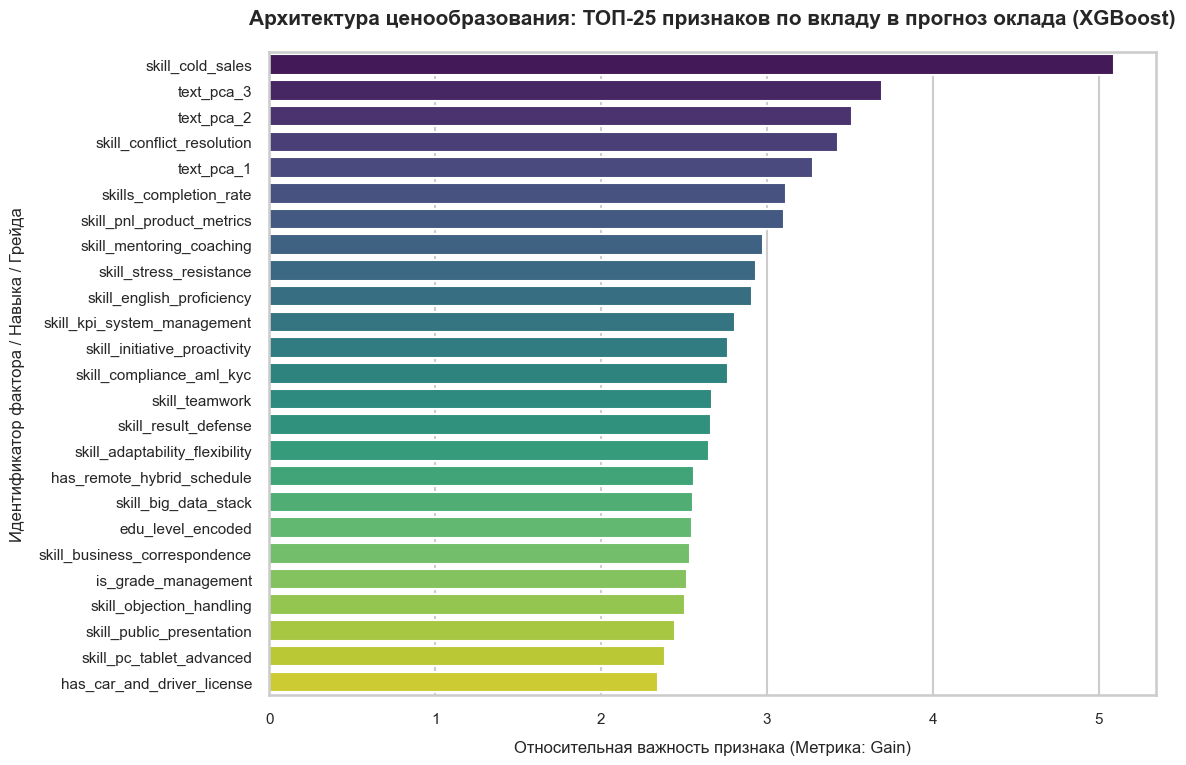

In [24]:
print("Анализ важности признаков лучшей модели XGBoost")

# Извлекаем веса важности (Gain — вклад признака в разделение узлов)
importance_scores = xgb_tuned.get_booster().get_score(importance_type='gain')

# Сопоставляем с именами колонок из матрицы X_linear (так как она использовалась для финального прохода)
feature_names = X_linear.columns
importance_data = []

for col_name in feature_names:
    clean_key = col_name.replace('[', '_').replace(']', '_').replace('<', '_')
    # Если признак не участвовал в сплитах, его вес равен 0
    score = importance_scores.get(col_name, importance_scores.get(clean_key, 0.0))
    importance_data.append({"Признак": col_name, "Важность (Gain)": score})

df_importance = pd.DataFrame(importance_data)
df_importance = df_importance.sort_values(by="Важность (Gain)", ascending=False).reset_index(drop=True)

# Топ-25 ключевых признаков для анализа
df_top_15 = df_importance.head(25).copy()

print("\n Топ-25 ключевых факторов ценообразования должностей:")
display(df_top_15)

# График
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid", context="talk")

sns.barplot(
    data=df_top_15,
    x='Важность (Gain)',
    y='Признак',
    palette='viridis',
    hue='Признак',
    legend=False
)

plt.title('Архитектура ценообразования: ТОП-25 признаков по вкладу в прогноз оклада (XGBoost)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Относительная важность признака (Метрика: Gain)', fontsize=12, labelpad=10)
plt.ylabel('Идентификатор фактора / Навыка / Грейда', fontsize=12, labelpad=10)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()